<a href="https://colab.research.google.com/github/kachytronico/programacion-ia-colab-labs/blob/main/energy_economics_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# 📝  Economía Energética


> Alfredo Ledesma Ruiz





## Supuesto

Una organización internacional nos ha facilitado un csv, que contiene series temporales anuales de distintos indicadores anonimizados para varios países entre 1995 y 2020. Nuestro objetivo será analizar la evolución histórica de los países y descubrir patrones comunes de comportamiento.

Para ello, deberemos realizar un estudio completo del conjunto de datos, tratando valores nulos, posibles atípicos, variables redundantes y transformaciones necesarias. A partir de las series temporales, construiremos un conjunto de características que resuma la dinámica de cada país a lo largo del tiempo.

El objetivo principal del problema será aplicar técnicas de aprendizaje **NO supervisado** para agrupar países según la evolución de sus indicadores, interpretar los grupos obtenidos y justificar su validez. Finalmente, podremos usar esas agrupaciones como pseudo-etiquetas para entrenar un modelo capaz de predecir a qué grupo pertenece un país a partir de sus datos temporales.

### Hitos

1. **RA1.** Carga el conjunto de datos y verifica su estructura temporal por país, comprobando duplicados y años faltantes. Realiza un análisis de correlación.
2. **RA2.** Elimina las columnas inútiles para el análisis.
3. **RA2.** Trata los valores nulos.
4. **RA2.** Estudia la dimensionalidad del conjunto de datos y reduce la dimensionalidad asegurando un 90% de la varianza.
5. **RA3.** Entrena un modelo KMeans. Usa técnicas para optimizar la elección de sus hiperparámetros.
6. **RA3.** Contrasta el agrupamiento anterior con un segundo enfoque usando **OTRO** modelo **NO** supervisado.
7. **RA3.** Usa los *clusters* obtenidos como pseudoetiquetas y entrena un modelo supervisado que permita predecir el país a partir de sus indicadores.
8. **RA3.** Interpreta el modelo final y justifica qué variables explican mejor la pertenencia a cada cluster.

## Clonado y preparar dataset

In [ ]:
!git clone https://github.com/ruescog/datasets

Cloning into 'datasets'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 60 (delta 0), reused 0 (delta 0), pack-reused 59 (from 2)
Receiving objects: 100% (60/60), 401.03 MiB | 40.37 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [ ]:
!unzip /content/datasets/PIA/2026/ORD1/P1.zip

Archive:  /content/datasets/PIA/2026/ORD1/P1.zip
  inflating: dataset.csv             


---

## Inspección estructural inicial



In [ ]:
import os
import pandas as pd

print("--- 1. BÚSQUEDA DE ARCHIVOS ---")
for root, dirs, files in os.walk('/content'):
    if 'sample_data' in root or '/.' in root:
        continue
    for file in files:
        if file.endswith(('.csv', '.tsv', '.parquet')):
            print(os.path.join(root, file))

# El dataset parece estar en la raíz según el estado del kernel
file_path = '/content/dataset.csv'

if os.path.exists(file_path):
    print(f"\n--- 2. CARGANDO DATASET: {file_path} ---")
    df = pd.read_csv(file_path)

    print("\n--- 3. INSPECCIÓN BÁSICA ---")
    print(f"Shape: {df.shape}")
    print(f"Duplicados absolutos: {df.duplicated().sum()}")
    print("\nHead:")
    display(df.head())
    print("\nInfo:")
    df.info()
    print("\nNulos por columna absolutos:")
    print(df.isnull().sum())

    print("\n--- 4. INVENTARIO ESTRUCTURAL ---")
    n_rows = len(df)
    for col in df.columns:
        dtype = df[col].dtype
        n_unique = df[col].nunique()
        pct_unique = (n_unique / n_rows) * 100 if n_rows > 0 else 0
        n_nulls = df[col].isnull().sum()
        pct_nulls = (n_nulls / n_rows) * 100 if n_rows > 0 else 0
        examples = df[col].dropna().unique()[:5]

        # Estimación simple de tipo estructural
        if pct_unique == 100 or col.lower() in ['id', 'index', 'codigo']:
            est_type = "ID/código"
        elif n_unique <= 1:
            est_type = "casi constante"
        elif n_unique == 2:
            est_type = "binaria"
        elif pd.api.types.is_datetime64_any_dtype(df[col]):
            est_type = "fecha"
        elif pd.api.types.is_numeric_dtype(df[col]):
            if n_unique > 20 and pct_unique > 1:
                est_type = "numérica continua"
            else:
                est_type = "numérica discreta"
        elif pd.api.types.is_object_dtype(df[col]):
            if pct_unique > 80:
                est_type = "texto libre"
            else:
                est_type = "categórica"
        else:
            est_type = "desconocido"

        print(f"Columna: {col}")
        print(f"  - Dtype: {dtype}")
        print(f"  - Únicos: {n_unique} ({pct_unique:.2f}%)")
        print(f"  - Nulos: {n_nulls} ({pct_nulls:.2f}%)")
        print(f"  - Ejemplos: {examples}")
        print(f"  - Tipo estructural estimado: {est_type}")
        print("-" * 40)
else:
    print(f"\nNo se encontró el archivo en la ruta {file_path}.")


--- 1. BÚSQUEDA DE ARCHIVOS ---
/content/dataset.csv

--- 2. CARGANDO DATASET: /content/dataset.csv ---

--- 3. INSPECCIÓN BÁSICA ---
Shape: (3354, 22)
Duplicados absolutos: 0

Head:


,Unnamed: 0,country_name,country_identifier,observation_year,a,b,c,d,e,f,...,i,j,k,l,m,n,o,p,q,r
0,0,Albania,1,1995,0.561661,2.925485966576154,28.432482,4743487914.072331,50.609710,0.218897271,...,1.806000e+08,1.132780,0.611710,7430.0,11.21,1167.57,27400.0,28750.0,3187784.0,2.330773
1,1,Albania,1,1996,0.564243,2.815940617719278,28.361314,5175145287.860251,51.636361,0.218897271,...,2.266400e+08,1.265499,0.621837,7150.0,10.95,1212.62,27400.0,28750.0,3168033.0,2.256921
2,2,Albania,1,1997,0.565246,2.1031528051091977,28.290146,4610020246.044928,55.953349,0.218897271,...,1.682300e+08,1.076889,0.470098,6420.0,11.18,868.01,27400.0,28750.0,3148281.0,2.039208
3,3,Albania,1,1998,0.569954,1.7678957926246204,28.218978,5017058469.28803,49.983365,0.1942044906,...,2.687400e+08,1.233094,0.575350,6670.0,11.81,1010.87,27400.0,28750.0,3128530.0,2.131992
4,4,Albania,1,1999,0.575831,1.2826413341929783,28.147810,5663797625.166139,42.718313,0.1942044906,...,4.881800e+08,1.447951,0.955359,7890.0,12.05,1138.70,27400.0,28750.0,3108778.0,2.537975



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3354 entries, 0 to 3353
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          3354 non-null   int64  
 1   country_name        3354 non-null   object 
 2   country_identifier  3354 non-null   int64  
 3   observation_year    3354 non-null   int64  
 4   a                   3224 non-null   float64
 5   b                   3342 non-null   object 
 6   c                   3354 non-null   float64
 7   d                   3336 non-null   object 
 8   e                   3347 non-null   float64
 9   f                   3068 non-null   object 
 10  g                   3354 non-null   float64
 11  h                   3353 non-null   float64
 12  i                   2663 non-null   float64
 13  j                   3236 non-null   float64
 14  k                   3354 non-null   float64
 15  l                   3354 non-null   float64
 16 

## Decisiones Previas

A partir de la exploración estructural inicial del dataset, he tomado las siguientes decisiones técnicas que guiarán el desarrollo del cuaderno:

- **Tarea y métricas:** El problema consta de dos fases. Primero, aprendizaje no supervisado (clustering) para agrupar los países, evaluado mediante la inercia (método del codo). Segundo, aprendizaje supervisado (clasificación multiclase) usando esos clústeres como pseudo-etiquetas, donde usaré la métrica **F1-score weighted** debido al más que probable desbalanceo de los grupos generados.
- **Patrón de validación:** Para la fase de clasificación, aplicaré un patrón *hold-out* estándar con un split del 20% para testeo, estratificado por el clúster asignado. Emplearé siempre `random_state = 33` para garantizar la reproducibilidad.
- **Estado inicial del dataset:** Contamos con un DataFrame de 3354 filas y 22 columnas (`df`), con presencia de valores nulos en múltiples variables predictoras (`a`, `b`, `d`, `e`, `f`, `h`, `i`, `j`) y tipos de datos mixtos.
- **Control de leakage y columnas irrelevantes:** Existen columnas como `Unnamed: 0` (índice) y `r` (100% valores únicos) que no aportan valor predictivo generalizable. Los identificadores como `country_name`, `country_identifier` y `observation_year` son útiles para el análisis de series temporales, pero no deben usarse directamente como características de entrada en el modelo final, ya que provocarían *data leakage* (memorización del país en lugar de aprendizaje de patrones).
- **Decisiones técnicas diferidas:**
  - La eliminación definitiva de columnas inútiles y el tratamiento de los valores nulos se realizarán de forma estructurada en los hitos de preprocesamiento.
  - La reducción de dimensionalidad requerida (90% de varianza retenida) se aplicará estrictamente después de imputar y escalar los datos.
- **Estado activo inicial:** El DataFrame crudo cargado en memoria (`df`) desde el archivo local.
- **Granularidad del clustering (decisión diferida clave):** El dataset tiene 3354 filas que son una observación por país y año (129 países × 26 años). El objetivo es agrupar países por la evolución temporal de sus indicadores, así que necesito construir features agregadas por país antes del clustering (estadísticos resumen, pendientes, niveles inicial/final por indicador). Esta construcción la haré en el bloque de preprocesamiento, antes del PCA y del KMeans.
- **Ambigüedad del target supervisado:** El texto del enunciado dice "predecir a qué grupo pertenece un país", pero el punto 7 dice "predecir el país". Asumo que el target del modelo supervisado son los clusters obtenidos (coherente con el espíritu de pseudo-etiquetas), no el nombre del país. Lo confirmaré antes de entrenar el modelo del Hito 7.
- **Tipos de datos a corregir:** Las columnas b, d y f están almacenadas como texto pero contienen valores numéricos. Las convertiré a numéricas en el primer hito de preprocesamiento.
- **Columna r:** Tiene el 100% de valores únicos pero es un float continuo, no parece un identificador. Decido revisarla en el AED antes de descartarla.
- **Identificadores y nulos:** Unnamed: 0 lo elimino sin discusión. country_name y country_identifier los conservo durante el preprocesamiento porque los necesito para agregar por país; los excluyo de las features del modelo final. Estado de nulos detectado: i con 20.60% (691/3354), f con 8.53% (286), y el resto residual <4%. El tratamiento se decide en el hito de nulos, viendo el patrón por país.

## Hito 1 — Carga, verificación temporal y correlación

En este primer paso reviso si el dataset está bien estructurado en el tiempo: cuántos años tengo por país, si me falta alguno y si hay duplicados a nivel país-año. Antes de eso, convierto a numéricas las columnas que vienen como texto para poder usarlas en el análisis de correlación. Termino con un heatmap y una tabla con los pares más correlacionados, que me servirán de pista para detectar redundancia y tratarla en el siguiente hito.

Delta de nulos por la conversión a numérico:
   nulos_antes  nulos_despues  delta
b           12             15      3
d           18             22      4
f          286            287      1

⚠️  Han aparecido NaNs nuevos tras la conversión en alguna columna.

VERIFICACIÓN TEMPORAL
Países totales: 129
Rango de años esperado: 1995-2020 (26 años)
Países con 26 años completos: 129
Países con menos de 26 años: 0

Duplicados en (country_name, observation_year): 0

MATRIZ DE CORRELACIÓN
Columnas usadas en la correlación (19): ['observation_year', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r']


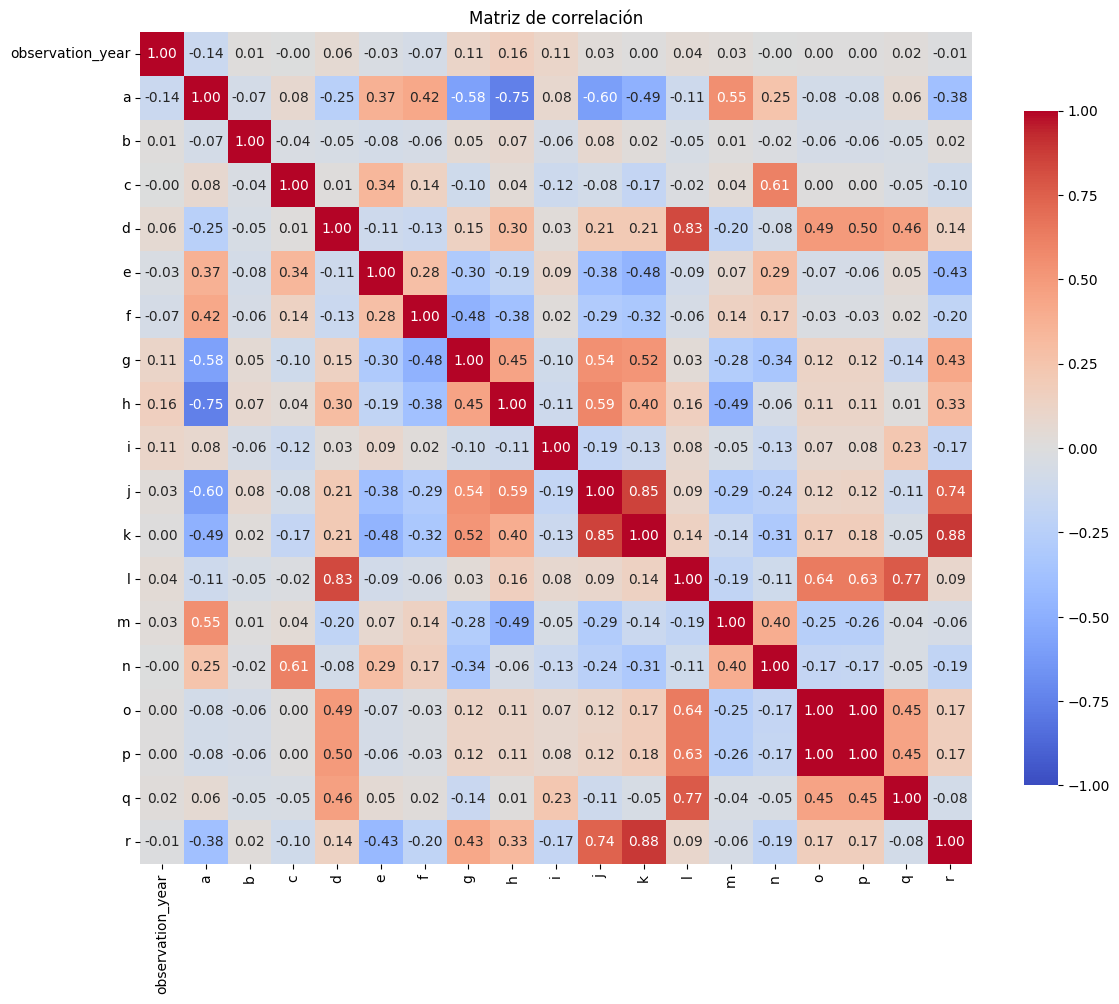


Pares con |correlación| >= 0.80:
variable_1 variable_2  correlacion
         o          p     0.999552
         k          r     0.884660
         j          k     0.853135
         d          l     0.830699


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 1) Conversión a numérico de columnas mal tipadas (b, d, f)
# ----------------------------------------------------------------------
cols_a_convertir = ['b', 'd', 'f']

nulos_antes = df[cols_a_convertir].isnull().sum()
for col in cols_a_convertir:
    df[col] = pd.to_numeric(df[col], errors='coerce')
nulos_despues = df[cols_a_convertir].isnull().sum()

delta_nulos = pd.DataFrame({
    'nulos_antes': nulos_antes,
    'nulos_despues': nulos_despues,
    'delta': nulos_despues - nulos_antes
})
print("Delta de nulos por la conversión a numérico:")
print(delta_nulos)

if (delta_nulos['delta'] > 0).any():
    print("\n⚠️  Han aparecido NaNs nuevos tras la conversión en alguna columna.")
else:
    print("\nNo aparecen NaNs nuevos tras la conversión.")

# ----------------------------------------------------------------------
# 2) Verificación de la estructura temporal por país
# ----------------------------------------------------------------------
print("\n" + "=" * 60)
print("VERIFICACIÓN TEMPORAL")
print("=" * 60)

anios_esperados = set(range(1995, 2021))  # 1995-2020 inclusive
n_paises = df['country_name'].nunique()
print(f"Países totales: {n_paises}")
print(f"Rango de años esperado: 1995-2020 ({len(anios_esperados)} años)")

anios_por_pais = df.groupby('country_name')['observation_year'].nunique()
paises_completos = (anios_por_pais == 26).sum()
paises_incompletos = anios_por_pais[anios_por_pais < 26]

print(f"Países con 26 años completos: {paises_completos}")
print(f"Países con menos de 26 años: {len(paises_incompletos)}")

if len(paises_incompletos) > 0:
    print("\nDetalle de países incompletos y años faltantes:")
    for pais, n in paises_incompletos.items():
        anios_pais = set(df.loc[df['country_name'] == pais, 'observation_year'])
        faltan = sorted(anios_esperados - anios_pais)
        print(f"  - {pais} ({n} años): faltan {faltan}")

# Duplicados a nivel (país, año)
dup_clave = df.duplicated(subset=['country_name', 'observation_year']).sum()
print(f"\nDuplicados en (country_name, observation_year): {dup_clave}")

# ----------------------------------------------------------------------
# 3) Análisis de correlación
# ----------------------------------------------------------------------
print("\n" + "=" * 60)
print("MATRIZ DE CORRELACIÓN")
print("=" * 60)

# Excluyo identificadores; mantengo observation_year para detectar tendencias temporales
cols_excluir = ['Unnamed: 0', 'country_identifier']
cols_numericas = df.select_dtypes(include='number').columns.tolist()
cols_corr = [c for c in cols_numericas if c not in cols_excluir]

print(f"Columnas usadas en la correlación ({len(cols_corr)}): {cols_corr}")

corr = df[cols_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8})
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

# Tabla auxiliar: pares con |corr| >= 0.80, sin diagonal ni duplicados (i,j)/(j,i)
mascara_triangular = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pares = corr.where(mascara_triangular).stack()
pares_altos = pares[pares.abs() >= 0.80].sort_values(key=abs, ascending=False)

print("\nPares con |correlación| >= 0.80:")
if len(pares_altos) > 0:
    df_pares = pares_altos.reset_index()
    df_pares.columns = ['variable_1', 'variable_2', 'correlacion']
    print(df_pares.to_string(index=False))
else:
    print("No hay pares con |correlación| >= 0.80.")

### Conclusión del Hito 1

**Estructura temporal.** El dataset es un panel limpio: 129 países, 26 años por país (1995-2020), sin huecos y sin duplicados a nivel (país, año). 129 × 26 = 3354 filas, exactamente el total observado. Esto significa que no necesito interpolar ni descartar países por series incompletas.

**Tipos corregidos.** Convertí `b`, `d` y `f` a numérico. La conversión generó 8 NaNs nuevos en total (3 en `b`, 4 en `d`, 1 en `f`), lo que indica que esas columnas tenían algunos valores no parseables como número en el CSV original. Son residuales (menos del 0.25% por columna) y los trato junto con los demás nulos cuando llegue el momento.

**Correlaciones altas detectadas.** Cuatro pares superan el umbral de |corr| ≥ 0.80:

| Variable 1 | Variable 2 | Correlación |
|---|---|---|
| o | p | 0.9996 |
| k | r | 0.8847 |
| j | k | 0.8531 |
| d | l | 0.8307 |

El par `o`/`p` es prácticamente una relación lineal perfecta y una de las dos columnas es redundante. `k` aparece en dos pares (`k`/`r` y `j`/`k`), por lo que merece atención especial al decidir qué eliminar. Estos pares marcan el material de trabajo para el siguiente hito, donde elimino las columnas inútiles incluyendo las redundantes.

**Estado activo.** `df` con 3354 filas y 22 columnas, ya con `b`, `d`, `f` numéricas. Listo para el hito de eliminación de columnas inútiles.

## Hito 2 — Eliminación de columnas inútiles

Reviso qué columnas no aportan información al análisis y cuáles son redundantes entre sí. Antes de eliminar nada, genero una tabla de diagnóstico que reúne, por columna, su rol provisional, sus nulos actuales y si participa en algún par correlacionado fuerte. Con esa tabla decidiré qué columnas se van y cuáles se quedan.

In [ ]:
# ----------------------------------------------------------------------
# Diagnóstico de columnas: rol provisional, nulos y pares correlacionados
# ----------------------------------------------------------------------

# Pares con |corr| >= 0.80 detectados en el Hito 1
pares_altos = [
    ('o', 'p', 0.9996),
    ('k', 'r', 0.8847),
    ('j', 'k', 0.8531),
    ('d', 'l', 0.8307),
]

# Conjunto de columnas que aparecen en algún par correlacionado
cols_en_pares = set()
for c1, c2, _ in pares_altos:
    cols_en_pares.update([c1, c2])

# Conteo de en cuántos pares aparece cada columna
apariciones_pares = {}
for c1, c2, _ in pares_altos:
    apariciones_pares[c1] = apariciones_pares.get(c1, 0) + 1
    apariciones_pares[c2] = apariciones_pares.get(c2, 0) + 1

# Rol provisional según el contexto del problema
def rol_provisional(col):
    if col == 'Unnamed: 0':
        return 'índice de exportación → eliminar'
    if col == 'country_identifier':
        return 'id numérico redundante con country_name'
    if col == 'country_name':
        return 'identificador de país (necesario para agregar)'
    if col == 'observation_year':
        return 'eje temporal (necesario para series)'
    return 'indicador anonimizado'

filas = []
for col in df.columns:
    nulos = df[col].isnull().sum()
    pct_nulos = nulos / len(df) * 100
    en_pares = col in cols_en_pares
    n_pares = apariciones_pares.get(col, 0)
    filas.append({
        'columna': col,
        'dtype': str(df[col].dtype),
        'nulos': nulos,
        '%_nulos': round(pct_nulos, 2),
        'en_par_correlacionado': en_pares,
        'n_pares': n_pares,
        'rol_provisional': rol_provisional(col),
    })

diag = pd.DataFrame(filas)
print("Diagnóstico por columna:")
print(diag.to_string(index=False))

# Resumen rápido de los pares para tener todo a la vista
print("\nPares correlacionados con detalle de nulos:")
for c1, c2, corr in pares_altos:
    n1 = df[c1].isnull().sum()
    n2 = df[c2].isnull().sum()
    print(f"  {c1} ({n1} nulos) vs {c2} ({n2} nulos)  |  corr = {corr}")

print(f"\nShape actual de df: {df.shape}")

Diagnóstico por columna:
           columna   dtype  nulos  %_nulos  en_par_correlacionado  n_pares                                rol_provisional
        Unnamed: 0   int64      0     0.00                  False        0               índice de exportación → eliminar
      country_name  object      0     0.00                  False        0 identificador de país (necesario para agregar)
country_identifier   int64      0     0.00                  False        0        id numérico redundante con country_name
  observation_year   int64      0     0.00                  False        0           eje temporal (necesario para series)
                 a float64    130     3.88                  False        0                          indicador anonimizado
                 b float64     15     0.45                  False        0                          indicador anonimizado
                 c float64      0     0.00                  False        0                          indicador anonimizado

In [ ]:
# ----------------------------------------------------------------------
# Subfase 3 — Eliminación de columnas inútiles y redundantes
# ----------------------------------------------------------------------
cols_a_eliminar = ['Unnamed: 0', 'country_identifier', 'k', 'p', 'd']

shape_antes = df.shape
cols_antes = list(df.columns)

df = df.drop(columns=cols_a_eliminar)

# ----------------------------------------------------------------------
# Subfase 4 — Verificación
# ----------------------------------------------------------------------
shape_despues = df.shape
cols_despues = list(df.columns)

print(f"Shape antes:    {shape_antes}")
print(f"Shape después:  {shape_despues}")
print(f"Columnas eliminadas ({len(cols_a_eliminar)}): {cols_a_eliminar}")
print(f"Columnas restantes ({len(cols_despues)}): {cols_despues}")

# Verificación de que no se han modificado filas, solo columnas
assert shape_antes[0] == shape_despues[0], "Se han perdido filas, revisar."
assert shape_despues[1] == shape_antes[1] - len(cols_a_eliminar), "Recuento de columnas inconsistente."

# Verificación de que ya no quedan pares con |corr| >= 0.80 entre los indicadores
indicadores = [c for c in df.columns if c not in ['country_name', 'observation_year']]
corr_post = df[indicadores].corr().abs()
mascara = np.triu(np.ones(corr_post.shape, dtype=bool), k=1)
pares_residuales = corr_post.where(mascara).stack()
pares_residuales = pares_residuales[pares_residuales >= 0.80].sort_values(ascending=False)

print("\nPares residuales con |corr| >= 0.80 tras la eliminación:")
if len(pares_residuales) > 0:
    print(pares_residuales)
else:
    print("Ninguno. Redundancia resuelta.")

print("\nNulos por columna en df actualizado:")
print(df.isnull().sum())

Shape antes:    (3354, 22)
Shape después:  (3354, 17)
Columnas eliminadas (5): ['Unnamed: 0', 'country_identifier', 'k', 'p', 'd']
Columnas restantes (17): ['country_name', 'observation_year', 'a', 'b', 'c', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'q', 'r']

Pares residuales con |corr| >= 0.80 tras la eliminación:
Ninguno. Redundancia resuelta.

Nulos por columna en df actualizado:
country_name          0
observation_year      0
a                   130
b                    15
c                     0
e                     7
f                   287
g                     0
h                     1
i                   691
j                   118
l                     0
m                     0
n                     0
o                     0
q                     0
r                     0
dtype: int64


### Conclusión del Hito 2

Eliminé cinco columnas que no aportaban valor analítico o introducían redundancia:

- **`Unnamed: 0`** y **`country_identifier`**: identificadores. El primero es un índice de exportación; el segundo duplica la información de `country_name` en formato numérico. Conservo `country_name` como identificador legible y `observation_year` como eje temporal, ambos imprescindibles para construir más adelante las características que resumen la dinámica de cada país.
- **`k`**: aparecía en dos de los cuatro pares correlacionados (`k`/`r` con 0.88 y `j`/`k` con 0.85). Eliminándola resolví ambos pares de una sola vez, conservando `r` y `j` que aportan información distinta.
- **`p`**: correlación 0.9996 con `o`, prácticamente la misma variable. Mantengo `o` por criterio alfabético, ya que ambas tenían 0 nulos.
- **`d`**: correlación 0.83 con `l`. Mantengo `l` porque tenía 0 nulos frente a los 22 de `d`.

Tras la eliminación, no queda ningún par de indicadores con |correlación| ≥ 0.80, por lo que la redundancia detectada en el Hito 1 está resuelta.

`df` pasa de 22 a 17 columnas, manteniendo las 3354 filas. Las columnas con más nulos pendientes (`i` con 20.60%, `f` con 8.56%) las trato en el siguiente hito.

**Estado activo:** `df` con 3354 filas y 17 columnas.

## Hito 3 — Tratamiento de valores nulos

Antes de imputar nada, quiero entender el patrón de los nulos. Como el dataset es un panel temporal por país, me interesa saber si los nulos se concentran en países concretos, en años iniciales o finales, o si están repartidos al azar. Esa estructura va a condicionar qué estrategia de imputación tiene sentido.

In [ ]:
# ----------------------------------------------------------------------
# Diagnóstico de nulos: distribución por columna, por país y por año
# ----------------------------------------------------------------------

cols_con_nulos = df.columns[df.isnull().any()].tolist()
print(f"Columnas con nulos: {cols_con_nulos}")

# 1) Resumen general por columna
resumen = pd.DataFrame({
    'nulos': df[cols_con_nulos].isnull().sum(),
    '%_nulos': (df[cols_con_nulos].isnull().sum() / len(df) * 100).round(2),
})
print("\nResumen de nulos por columna:")
print(resumen.to_string())

# 2) Concentración por país: ¿los nulos están en pocos países o repartidos?
print("\n" + "=" * 60)
print("CONCENTRACIÓN DE NULOS POR PAÍS (top 10 por columna afectada)")
print("=" * 60)

for col in cols_con_nulos:
    nulos_pais = df[df[col].isnull()].groupby('country_name').size().sort_values(ascending=False)
    if len(nulos_pais) == 0:
        continue
    n_paises_afectados = len(nulos_pais)
    paises_con_serie_completa_nula = (nulos_pais == 26).sum()
    print(f"\nColumna '{col}': {nulos_pais.sum()} nulos en {n_paises_afectados} países")
    print(f"  Países con los 26 años nulos: {paises_con_serie_completa_nula}")
    print(f"  Top 10 países con más nulos:")
    print(nulos_pais.head(10).to_string())

# 3) Patrón temporal: ¿los nulos se concentran en años iniciales/finales?
print("\n" + "=" * 60)
print("DISTRIBUCIÓN DE NULOS POR AÑO")
print("=" * 60)

nulos_por_año = df.groupby('observation_year')[cols_con_nulos].apply(
    lambda x: x.isnull().sum()
)
print(nulos_por_año.to_string())

Columnas con nulos: ['a', 'b', 'e', 'f', 'h', 'i', 'j']

Resumen de nulos por columna:
   nulos  %_nulos
a    130     3.88
b     15     0.45
e      7     0.21
f    287     8.56
h      1     0.03
i    691    20.60
j    118     3.52

CONCENTRACIÓN DE NULOS POR PAÍS (top 10 por columna afectada)

Columna 'a': 130 nulos en 5 países
  Países con los 26 años nulos: 5
  Top 10 países con más nulos:
country_name
Bahamas, The           26
Djibouti               26
Equatorial Guinea      26
St. Kitts and Nevis    26
St. Lucia              26

Columna 'b': 15 nulos en 3 países
  Países con los 26 años nulos: 0
  Top 10 países con más nulos:
country_name
Montenegro     12
Iraq            2
El Salvador     1

Columna 'e': 7 nulos en 1 países
  Países con los 26 años nulos: 0
  Top 10 países con más nulos:
country_name
Montenegro    7

Columna 'f': 287 nulos en 12 países
  Países con los 26 años nulos: 11
  Top 10 países con más nulos:
country_name
Antigua and Barbuda    26
Bahamas, The           26

In [ ]:
# ----------------------------------------------------------------------
# Subfase 3 — Tratamiento de nulos
# Estrategia: eliminar columnas con nulos estructurales (i, f, a)
#             imputar el resto con mediana por país, fallback mediana global
# ----------------------------------------------------------------------

cols_a_eliminar = ['i', 'f', 'a']
cols_a_imputar = ['b', 'e', 'h', 'j']  # nulos puntuales o series cortas

shape_antes = df.shape
nulos_antes = df.isnull().sum().sum()

# 1) Eliminar columnas con nulos estructurales
df = df.drop(columns=cols_a_eliminar)
print(f"Columnas eliminadas por nulos estructurales: {cols_a_eliminar}")
print(f"Shape tras eliminación: {df.shape}")

# 2) Imputar el resto con mediana del país, fallback mediana global
print("\nImputación por columna (mediana por país, fallback mediana global):")

for col in cols_a_imputar:
    nulos_pre = df[col].isnull().sum()

    # Mediana por país
    mediana_pais = df.groupby('country_name')[col].transform('median')
    df[col] = df[col].fillna(mediana_pais)

    # Fallback mediana global para países que no tenían ningún dato en la columna
    nulos_tras_pais = df[col].isnull().sum()
    if nulos_tras_pais > 0:
        mediana_global = df[col].median()
        df[col] = df[col].fillna(mediana_global)
        print(f"  {col}: imputados {nulos_pre - nulos_tras_pais} con mediana del país, "
              f"{nulos_tras_pais} con mediana global ({mediana_global:.4f})")
    else:
        print(f"  {col}: imputados {nulos_pre} con mediana del país (sin fallback necesario)")

# ----------------------------------------------------------------------
# Subfase 4 — Verificación
# ----------------------------------------------------------------------
print("\n" + "=" * 60)
print("VERIFICACIÓN")
print("=" * 60)

shape_despues = df.shape
nulos_despues = df.isnull().sum().sum()

print(f"Shape antes:    {shape_antes}")
print(f"Shape después:  {shape_despues}")
print(f"Nulos totales antes:    {nulos_antes}")
print(f"Nulos totales después:  {nulos_despues}")

print(f"\nNulos por columna actualmente:")
print(df.isnull().sum())

# Comprobaciones duras
assert nulos_despues == 0, "Quedan nulos sin tratar."
assert shape_despues[0] == shape_antes[0], "Se han perdido filas."
assert shape_despues[1] == shape_antes[1] - len(cols_a_eliminar), "Recuento de columnas inconsistente."

print(f"\nColumnas restantes ({df.shape[1]}): {list(df.columns)}")

Columnas eliminadas por nulos estructurales: ['i', 'f', 'a']
Shape tras eliminación: (3354, 14)

Imputación por columna (mediana por país, fallback mediana global):
  b: imputados 15 con mediana del país (sin fallback necesario)
  e: imputados 7 con mediana del país (sin fallback necesario)
  h: imputados 1 con mediana del país (sin fallback necesario)
  j: imputados 14 con mediana del país, 104 con mediana global (3.2536)

VERIFICACIÓN
Shape antes:    (3354, 17)
Shape después:  (3354, 14)
Nulos totales antes:    1249
Nulos totales después:  0

Nulos por columna actualmente:
country_name        0
observation_year    0
b                   0
c                   0
e                   0
g                   0
h                   0
j                   0
l                   0
m                   0
n                   0
o                   0
q                   0
r                   0
dtype: int64

Columnas restantes (14): ['country_name', 'observation_year', 'b', 'c', 'e', 'g', 'h', 'j', 'l',

### Conclusión del Hito 3

El diagnóstico mostró que los nulos no son ruido aleatorio sino un patrón estructural: en varias columnas, los nulos correspondían a países enteros sin dato en los 26 años. Imputar esas series completas habría sido inventar información, así que las traté de forma diferenciada según su naturaleza:

- **Eliminé las columnas `i`, `f` y `a`.** En `i` había 26 países OECD con la serie entera vacía (676 de los 691 nulos), en `f` 11 países completos sin dato (286 de 287) y en `a` 5 países completos (130 de 130). En esos casos no se trata de un valor desconocido puntual sino de un indicador no medido para esos países: imputarlo distorsionaría el clustering posterior. El resto del dataset queda intacto.

- **Imputé las columnas `b`, `e`, `h` y `j` con mediana por país.** Estos casos sí son nulos puntuales o series cortas dentro de países que sí reportan el indicador. Usar la mediana del propio país es coherente con la naturaleza panel del dataset: aprovecho los años en que ese país sí tiene dato en lugar de imponerle una mediana global ajena. Para los países donde la columna no tenía ningún dato (caso de `j` en Islandia, Maldivas, St. Kitts y Seychelles, donde la serie completa era nula), apliqué mediana global como fallback.

`df` queda con 3354 filas y 14 columnas, sin nulos. La estructura temporal se mantiene intacta: 129 países × 26 años.

**Estado activo:** `df` con 3354 filas y 14 columnas (`country_name`, `observation_year`, `b`, `c`, `e`, `g`, `h`, `j`, `l`, `m`, `n`, `o`, `q`, `r`), sin nulos. Listo para construir las features de dinámica temporal y reducir dimensionalidad.

## Hito 3.5 — Construcción de características por país

El enunciado pide agrupar países según la evolución temporal de sus indicadores y, en el preámbulo, indica que hay que construir un conjunto de características que resuma esa dinámica por país. Antes de aplicar PCA y clustering necesito una matriz con una fila por país, no por país-año. Para cada indicador calculo tres estadísticos que capturan nivel, volatilidad y tendencia: media, desviación típica y pendiente lineal en el tiempo. Resultado: 129 países descritos por 36 features.

In [ ]:
# ----------------------------------------------------------------------
# Construcción de features por país a partir del panel temporal
# Para cada indicador: media, std y slope (pendiente lineal en el tiempo)
# ----------------------------------------------------------------------

indicadores = ['b', 'c', 'e', 'g', 'h', 'j', 'l', 'm', 'n', 'o', 'q', 'r']

def calcular_slope(serie_temporal, anios):
    # Pendiente de la regresión lineal del indicador en el tiempo
    return np.polyfit(anios, serie_temporal, 1)[0]

filas = []
for pais, grupo in df.groupby('country_name'):
    grupo = grupo.sort_values('observation_year')
    anios = grupo['observation_year'].values

    fila = {'country_name': pais}
    for col in indicadores:
        valores = grupo[col].values
        fila[f'{col}_mean']  = valores.mean()
        fila[f'{col}_std']   = valores.std()
        fila[f'{col}_slope'] = calcular_slope(valores, anios)
    filas.append(fila)

df_paises = pd.DataFrame(filas).set_index('country_name')

# Verificación
print(f"Shape de df_paises: {df_paises.shape}")
print(f"Nulos totales: {df_paises.isnull().sum().sum()}")
print(f"Países: {df_paises.shape[0]}")
print(f"Features por país: {df_paises.shape[1]}")

print("\nPrimeras filas de df_paises:")
display(df_paises.head())

print("\nResumen estadístico de las features:")
display(df_paises.describe().round(4))

Shape de df_paises: (129, 36)
Nulos totales: 0
Países: 129
Features por país: 36

Primeras filas de df_paises:


,b_mean,b_std,b_slope,c_mean,c_std,c_slope,e_mean,e_std,e_slope,g_mean,...,n_slope,o_mean,o_std,o_slope,q_mean,q_std,q_slope,r_mean,r_std,r_slope
country_name,,,,,,,,,,,,,,,,,,,,,
Albania,6.027274,2.879433,0.304931,28.473849,0.243922,0.028761,39.712274,5.890889,-0.421978,49.732808,...,2.545255,2.740000e+04,0.000000,2.961357e-13,2.982636e+06,1.060370e+05,-13869.318632,3.006384,0.447325,0.056293
Algeria,0.986163,0.548144,-0.003673,0.753836,0.060959,0.007674,0.318817,0.159772,-0.017976,65.396731,...,-0.328253,2.381740e+06,0.421325,4.102564e-02,3.526148e+07,4.477114e+06,590882.041026,4.571922,0.576499,0.074749
Angola,4.843279,10.670932,-0.877625,58.807321,3.081299,-0.408511,60.666204,9.938826,-1.134574,56.915654,...,1.174526,1.246700e+06,0.000000,6.933118e-12,2.209886e+07,5.753921e+06,761750.461197,3.241938,0.316998,-0.016246
Antigua and Barbuda,10.128747,6.908579,0.053767,20.337850,1.135234,-0.151364,0.193775,0.324023,0.034053,28.366192,...,-8.181675,4.400000e+02,0.000000,3.080986e-15,8.448331e+04,8.844544e+03,1177.156923,10.814070,3.076301,0.269211
Argentina,2.298530,1.434452,-0.081665,11.398638,0.701248,-0.092814,9.826942,1.089743,-0.048995,90.330269,...,-1.964950,2.736690e+06,0.000000,-4.954541e-12,3.997436e+07,3.140971e+06,418589.621538,8.086464,0.376785,0.036523



Resumen estadístico de las features:


,b_mean,b_std,b_slope,c_mean,c_std,c_slope,e_mean,e_std,e_slope,g_mean,...,n_slope,o_mean,o_std,o_slope,q_mean,q_std,q_slope,r_mean,r_std,r_slope
count,129.0000,129.0000,129.0000,129.0000,129.0000,129.0000,129.0000,129.0000,129.0000,129.0000,...,129.0000,1.290000e+02,129.0000,129.0000,1.290000e+02,1.290000e+02,1.290000e+02,129.0000,129.0000,129.0000
mean,5.7729,5.6748,0.0183,32.1036,0.9505,-0.0072,21.5503,4.1344,-0.0950,62.9772,...,-0.5962,8.332845e+05,584.7288,6.3100,4.475967e+07,3.607563e+06,4.620714e+05,8.7605,1.1819,-0.0119
std,9.1133,13.5662,0.6040,23.6849,1.2612,0.2033,20.3739,3.9822,0.6467,19.5468,...,4.4990,2.211932e+06,2611.2441,243.8528,1.592893e+08,1.280806e+07,1.709637e+06,7.7183,1.2886,0.1605
min,-1.4072,0.2962,-3.0933,0.0000,0.0000,-0.8605,0.0000,0.0000,-3.0895,18.3468,...,-10.6153,2.600000e+02,0.0000,-731.5214,4.775692e+04,6.148448e+02,-2.799038e+05,1.0184,0.0810,-0.6140
25%,2.0182,1.4623,-0.0817,11.6291,0.1432,-0.0521,5.0439,1.3313,-0.4055,48.9512,...,-2.5687,2.805000e+04,0.0000,-0.0000,2.027847e+06,1.234528e+05,4.525030e+03,3.4190,0.3674,-0.0785
50%,3.5373,2.3462,-0.0031,30.8943,0.5561,0.0050,15.2899,3.3140,0.0007,65.0838,...,-0.1107,1.203400e+05,0.0000,0.0000,6.984954e+06,5.386870e+05,6.051721e+04,6.5140,0.7334,0.0174
75%,6.2173,4.4163,0.0634,50.9172,1.2363,0.0730,32.8615,5.5292,0.2564,77.8268,...,1.1790,4.994190e+05,55.4349,0.0000,2.849958e+07,2.331128e+06,3.089308e+05,10.9743,1.4119,0.0528
max,74.6025,120.1753,5.3983,98.0614,7.0349,0.8481,89.1831,26.7115,1.3299,100.0000,...,30.5695,1.637869e+07,25991.3906,2367.4000,1.318938e+09,1.261527e+08,1.679694e+07,45.9488,8.3265,0.3806


### Conclusión del Hito 3.5

Construí `df_paises`, una matriz con una fila por país y 36 columnas (12 indicadores × 3 estadísticos: media, desviación típica y pendiente lineal en el tiempo). Los 129 países quedan así descritos por un único vector de features que resume su dinámica entre 1995 y 2020, sin nulos.

Detecto dos cosas que condicionan el siguiente paso. Primero, las features están en escalas muy diferentes: `q_mean` ronda 10⁷ y llega a 10⁹, mientras que `b_mean` está en torno a 5. Antes de aplicar PCA tendré que escalar con StandardScaler para que la varianza no quede dominada por la magnitud bruta. Segundo, hay países donde el indicador `o` es prácticamente constante en el tiempo (std y slope cercanos a cero); es información real del panel, no un error, y la dejo tal cual.

**Estado activo:** `df_paises` con 129 filas y 36 columnas, indexado por `country_name`. `df` original se conserva intacto por trazabilidad.

## Hito 4 — Estudio de dimensionalidad y reducción con PCA

Las features que construí en el paso anterior viven en escalas muy distintas, así que primero escalo con StandardScaler y después aplico PCA. Para entender la dimensionalidad real del problema, en este primer paso ajusto el PCA sin limitar el número de componentes y miro cuánta varianza acumula cada uno. Eso me dice cuántos componentes necesito para asegurar el 90% que pide el enunciado.

Shape de df_paises original: (129, 36)
Shape tras escalado:         (129, 36)
Media tras escalado (debe ≈ 0):       0.000000
Desviación tras escalado (debe ≈ 1):  1.000000

Varianza explicada por componente (top 15):
 componente  varianza_individual  varianza_acumulada
          1             0.182945            0.182945
          2             0.150818            0.333763
          3             0.080692            0.414455
          4             0.065808            0.480263
          5             0.062522            0.542785
          6             0.056532            0.599317
          7             0.048381            0.647698
          8             0.040444            0.688142
          9             0.037637            0.725779
         10             0.032749            0.758528
         11             0.029972            0.788500
         12             0.026948            0.815449
         13             0.024814            0.840262
         14             0.020691         

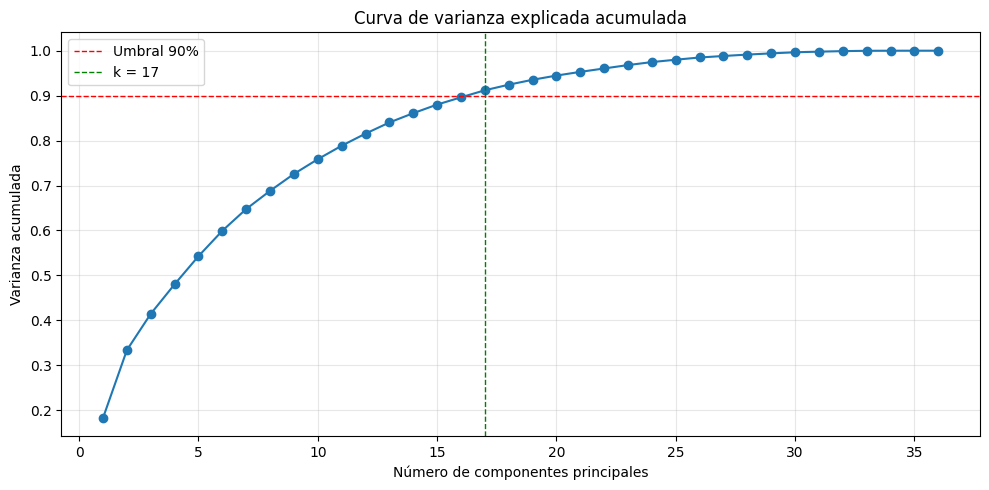

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

random_seed = 33

# ----------------------------------------------------------------------
# 1) Escalado con StandardScaler
# ----------------------------------------------------------------------
scaler = StandardScaler()
X_paises_scaled = scaler.fit_transform(df_paises)

print(f"Shape de df_paises original: {df_paises.shape}")
print(f"Shape tras escalado:         {X_paises_scaled.shape}")
print(f"Media tras escalado (debe ≈ 0):       {X_paises_scaled.mean():.6f}")
print(f"Desviación tras escalado (debe ≈ 1):  {X_paises_scaled.std():.6f}")

# ----------------------------------------------------------------------
# 2) PCA exploratorio: ajustar con todos los componentes posibles
# ----------------------------------------------------------------------
pca_explorer = PCA(random_state=random_seed)
pca_explorer.fit(X_paises_scaled)

var_indiv  = pca_explorer.explained_variance_ratio_
var_acum   = np.cumsum(var_indiv)

# Tabla numérica auxiliar: varianza por componente
tabla_var = pd.DataFrame({
    'componente': np.arange(1, len(var_indiv) + 1),
    'varianza_individual': var_indiv.round(6),
    'varianza_acumulada':  var_acum.round(6),
})
print("\nVarianza explicada por componente (top 15):")
print(tabla_var.head(15).to_string(index=False))

# ----------------------------------------------------------------------
# 3) Identificar k mínimo que asegure ≥ 90%
# ----------------------------------------------------------------------
k_min = int(np.searchsorted(var_acum, 0.90) + 1)
print(f"\nNúmero mínimo de componentes para ≥ 90% varianza: k = {k_min}")
print(f"Varianza acumulada con k={k_min} componentes: {var_acum[k_min-1]:.4f}")
print(f"Varianza acumulada con k={k_min-1} componentes: {var_acum[k_min-2]:.4f}")

# ----------------------------------------------------------------------
# 4) Curva de varianza acumulada con marca al 90%
# ----------------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(var_acum) + 1), var_acum, marker='o', linewidth=1.5)
plt.axhline(0.90, color='red', linestyle='--', linewidth=1, label='Umbral 90%')
plt.axvline(k_min, color='green', linestyle='--', linewidth=1, label=f'k = {k_min}')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza acumulada')
plt.title('Curva de varianza explicada acumulada')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------------------------------------------------
# Subfase 2 — Aplicar PCA con n_components=0.90 (umbral de varianza)
# ----------------------------------------------------------------------

pca = PCA(n_components=0.90, random_state=random_seed)
X_paises_pca = pca.fit_transform(X_paises_scaled)

# Construir DataFrame con los componentes resultantes manteniendo el índice de país
columnas_pca = [f'PC{i+1}' for i in range(X_paises_pca.shape[1])]
df_paises_pca = pd.DataFrame(
    X_paises_pca,
    index=df_paises.index,
    columns=columnas_pca,
)

# Verificación
print(f"Shape de df_paises original:    {df_paises.shape}")
print(f"Shape tras escalado:            {X_paises_scaled.shape}")
print(f"Shape tras PCA al 90%:          {df_paises_pca.shape}")
print(f"Componentes seleccionados:      {pca.n_components_}")
print(f"Varianza acumulada total:       {pca.explained_variance_ratio_.sum():.4f}")

# Comprobaciones duras
assert pca.explained_variance_ratio_.sum() >= 0.90, "El PCA no asegura el 90% de varianza."
assert df_paises_pca.shape[0] == df_paises.shape[0], "Se han perdido países."
assert df_paises_pca.index.equals(df_paises.index), "El índice de países no coincide."

print("\nPrimeras filas de df_paises_pca:")
display(df_paises_pca.head())

Shape de df_paises original:    (129, 36)
Shape tras escalado:            (129, 36)
Shape tras PCA al 90%:          (129, 17)
Componentes seleccionados:      17
Varianza acumulada total:       0.9119

Primeras filas de df_paises_pca:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17
country_name,,,,,,,,,,,,,,,,,
Albania,-1.155247,-0.246535,-1.670202,0.000769,-0.185834,2.447735,0.509663,-0.124235,0.733256,0.471888,0.753037,0.898086,0.267532,0.876722,-0.138633,-0.952029,1.146459
Algeria,-1.229978,0.150935,-0.442695,-3.405619,-0.375668,0.388110,1.163008,-1.314615,0.864964,0.280516,-0.528312,0.146330,0.058906,0.462722,0.210540,0.294665,-0.283889
Angola,-4.443649,-0.952803,0.397119,0.146161,-0.503708,2.206919,1.337613,-1.452922,-1.397025,-1.490393,0.677117,0.504818,1.076180,0.348001,-0.447217,0.693216,-0.264803
Antigua and Barbuda,-1.100463,-1.956737,1.790594,-1.182760,0.572165,-1.766345,-1.730911,0.920290,1.024656,0.270657,-1.309486,-1.135283,-0.320576,-1.418396,-0.358664,-0.530249,0.587328
Argentina,0.089331,-0.061154,-0.664284,-1.758103,-0.324978,-0.796284,0.512944,-0.980094,-0.147940,-0.648657,-1.264023,-0.590243,0.113778,0.014419,-0.230940,0.961080,-0.802056


### Conclusión del Hito 4

El estudio de dimensionalidad muestra que la varianza no se concentra en pocos componentes: el primero solo explica el 18.3% y el segundo el 15.1%. Para alcanzar el 90% que exige el enunciado necesito 17 componentes, que acumulan el 91.19%; con 16 me quedaría en 89.62%, justo por debajo del umbral.

Eso me dice algo sobre la naturaleza del problema: los 12 indicadores anonimizados, una vez resumidos por país en media, desviación y pendiente, capturan dinámicas relativamente independientes entre sí. No hay un eje dominante de variación que separe a los países; las diferencias se reparten en muchas dimensiones.

Antes del PCA escalé con StandardScaler porque las features convivían en órdenes de magnitud muy distintos (de 10⁰ en `b` a 10⁹ en `q`). El escalado dejó la matriz con media ≈ 0 y desviación ≈ 1, condición necesaria para que la varianza no quede dominada por la escala bruta.

`df_paises_pca` queda con 129 filas (una por país) y 17 columnas (`PC1` a `PC17`), preservando el índice por nombre de país. Esta es la matriz de entrada para el clustering del siguiente hito.

**Estado activo:** `df_paises_pca` con 129 filas y 17 columnas, indexado por `country_name`. `df_paises` y `df` se conservan para trazabilidad. `scaler` y `pca` quedan ajustados por si fueran necesarios más adelante.

## Hito 5 — Clustering con KMeans y optimización del número de clusters

Agrupo los 129 países usando KMeans sobre la matriz reducida del paso anterior. El número de clusters no se elige a ojo: aplico tres técnicas complementarias para optimizarlo. Primero el método del codo (que mide la cohesión intra-cluster a través de la inercia), después el silhouette score (que mide cómo de bien separados quedan los grupos) y finalmente el índice Davies-Bouldin (que combina dispersión intra-cluster y separación entre clusters). Tras una primera lectura de las tres curvas y una verificación posterior de la composición de los clusters, ajusto K para evitar que el modelo se quede dominado por outliers extremos del dataset.

Estudio de K con tres técnicas de optimización:
 K   inercia  silhouette  davies_bouldin  delta_inercia  mejora_relativa_%
 2 3612.5128      0.1772          2.0677            NaN                NaN
 3 3032.5355      0.1746          1.5606       579.9773              16.05
 4 2783.9563      0.1822          1.3281       248.5792               8.20
 5 2576.5646      0.1716          1.4066       207.3917               7.45
 6 2415.7757      0.1651          1.5220       160.7889               6.24
 7 2179.3452      0.1318          1.4030       236.4306               9.79
 8 2060.6604      0.1409          1.4009       118.6847               5.45
 9 1872.9247      0.1383          1.2397       187.7358               9.11
10 1732.4671      0.1396          1.1071       140.4576               7.50


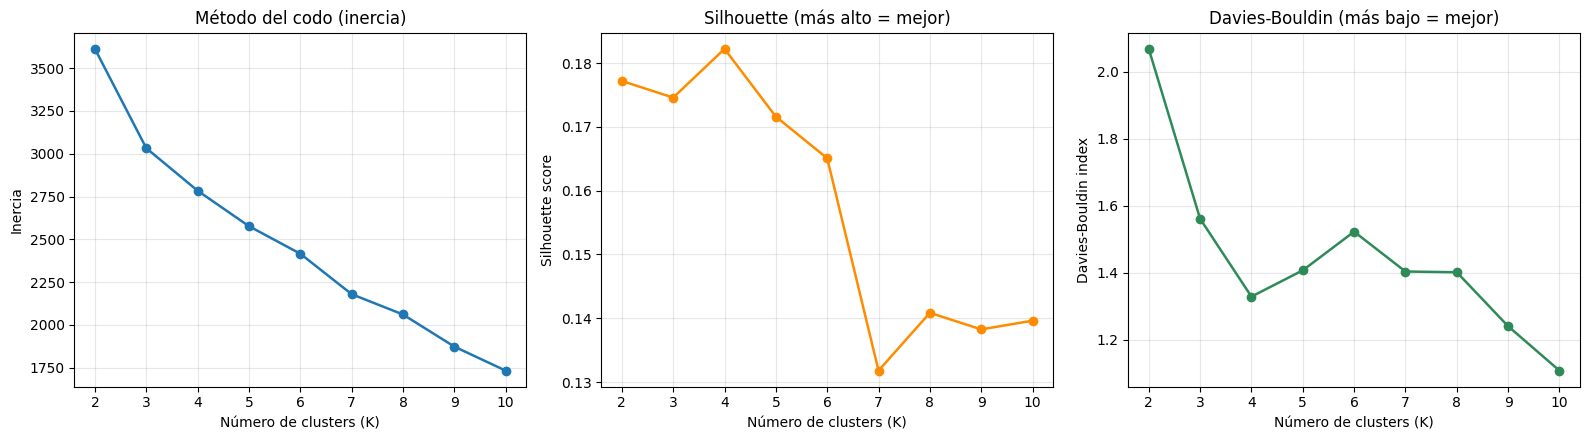


Mejor K según silhouette: K = 4 (silhouette = 0.1822)
Mejor K según Davies-Bouldin: K = 10 (DB = 1.1071)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

random_seed = 33

# ----------------------------------------------------------------------
# Estudio de K con tres técnicas de optimización:
#   1) Método del codo (inercia) — mide cohesión intra-cluster
#   2) Silhouette score — mide separación entre clusters (más alto = mejor)
#   3) Davies-Bouldin index — ratio dispersión/separación (más bajo = mejor)
# ----------------------------------------------------------------------

rango_k = range(2, 11)
resultados = []

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=random_seed, n_init=10)
    etiquetas = km.fit_predict(df_paises_pca)
    resultados.append({
        'K': k,
        'inercia': km.inertia_,
        'silhouette': silhouette_score(df_paises_pca, etiquetas),
        'davies_bouldin': davies_bouldin_score(df_paises_pca, etiquetas),
    })

tabla_k = pd.DataFrame(resultados)
tabla_k['delta_inercia'] = tabla_k['inercia'].diff().abs()
tabla_k['mejora_relativa_%'] = (tabla_k['delta_inercia'] / tabla_k['inercia'].shift(1) * 100).round(2)

print("Estudio de K con tres técnicas de optimización:")
print(tabla_k.round(4).to_string(index=False))

# ----------------------------------------------------------------------
# Tres curvas en paralelo: codo, silhouette y Davies-Bouldin
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(tabla_k['K'], tabla_k['inercia'], marker='o', linewidth=1.8)
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo (inercia)')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(rango_k))

axes[1].plot(tabla_k['K'], tabla_k['silhouette'], marker='o', color='darkorange', linewidth=1.8)
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette (más alto = mejor)')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(rango_k))

axes[2].plot(tabla_k['K'], tabla_k['davies_bouldin'], marker='o', color='seagreen', linewidth=1.8)
axes[2].set_xlabel('Número de clusters (K)')
axes[2].set_ylabel('Davies-Bouldin index')
axes[2].set_title('Davies-Bouldin (más bajo = mejor)')
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(list(rango_k))

plt.tight_layout()
plt.show()

# Mejor K según cada criterio
mejor_k_silhouette = int(tabla_k.loc[tabla_k['silhouette'].idxmax(), 'K'])
mejor_k_davies = int(tabla_k.loc[tabla_k['davies_bouldin'].idxmin(), 'K'])

print(f"\nMejor K según silhouette: K = {mejor_k_silhouette} "
      f"(silhouette = {tabla_k['silhouette'].max():.4f})")
print(f"Mejor K según Davies-Bouldin: K = {mejor_k_davies} "
      f"(DB = {tabla_k['davies_bouldin'].min():.4f})")

In [ ]:
# ----------------------------------------------------------------------
# Comparativa de distribución de clusters para K candidatos
# Antes de fijar K, quiero ver tamaños mínimos y reparto de países
# ----------------------------------------------------------------------

candidatos_k = [2, 3, 4]
comparativa = []

for k in candidatos_k:
    km_test = KMeans(n_clusters=k, random_state=random_seed, n_init=10)
    etiq_test = km_test.fit_predict(df_paises_pca)
    distrib = pd.Series(etiq_test).value_counts().sort_index()

    sil = silhouette_score(df_paises_pca, etiq_test)

    fila = {
        'K': k,
        'silhouette': round(sil, 4),
        'inercia': round(km_test.inertia_, 2),
        'tam_min': int(distrib.min()),
        'tam_max': int(distrib.max()),
        'distribucion': distrib.tolist(),
    }
    comparativa.append(fila)

df_comp = pd.DataFrame(comparativa)
print("Comparativa de K candidatos:")
print(df_comp.to_string(index=False))

# Para cada K candidato, mostrar muestra de países por cluster
for k in candidatos_k:
    print(f"\n{'=' * 60}")
    print(f"K = {k} — composición de clusters")
    print('=' * 60)
    km_test = KMeans(n_clusters=k, random_state=random_seed, n_init=10)
    etiq_test = km_test.fit_predict(df_paises_pca)

    df_test = df_paises_pca.copy()
    df_test['cluster'] = etiq_test

    for c in range(k):
        paises_c = df_test[df_test['cluster'] == c].index.tolist()
        muestra = paises_c[:10]
        print(f"\n  Cluster {c} ({len(paises_c)} países):")
        print(f"    {muestra}{'...' if len(paises_c) > 10 else ''}")

Comparativa de K candidatos:
 K  silhouette  inercia  tam_min  tam_max   distribucion
 2      0.1772  3612.51       56       73       [73, 56]
 3      0.1746  3032.54        2       65    [65, 62, 2]
 4      0.1822  2783.96        2       63 [2, 63, 62, 2]

K = 2 — composición de clusters

  Cluster 0 (73 países):
    ['Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas, The', 'Bahrain', 'Belarus', 'Belgium', 'Bosnia and Herzegovina']...

  Cluster 1 (56 países):
    ['Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Bangladesh', 'Barbados', 'Belize', 'Bhutan', 'Bolivia', 'Botswana']...

K = 3 — composición de clusters

  Cluster 0 (65 países):
    ['Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas, The', 'Bahrain', 'Belarus', 'Belgium', 'Brunei Darussalam', 'Bulgaria']...

  Cluster 1 (62 países):
    ['Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Bangladesh', 'Barbados', 'Belize', 'Bhutan', 'Bolivia']...

  Cluster 2 (2 países):

### Análisis de la composición de clusters y elección final del K

La primera lectura del codo y del silhouette apuntaba a K=4 (silhouette máximo de 0.1822 y mejora de inercia razonable). Antes de aceptar ese valor, comprobé la composición de los clusters y encontré un problema: con K=4, dos de los cuatro grupos quedaban formados por solo 2 países cada uno (China e India por un lado, Chipre y Malta por otro). Lo mismo ocurre con K=3, donde China e India vuelven a formar un cluster aislado de 2 países.

Esto pasa porque algunos países del dataset son outliers extremos en términos de dinámica económica: China e India por su escala demográfica y económica única, y Chipre y Malta por ser micro-estados insulares con patrones de servicios financieros muy específicos. KMeans tiende a aislarlos en sus propios grupos, lo que infla artificialmente el silhouette pero genera clusters degenerados que no son utilizables para el modelo supervisado del paso siguiente (con stratify, un cluster de 2 países deja un solo país en train).

K=2 es el único candidato del rango analizado que produce un reparto sin clusters degenerados (73 vs 56 países), con un silhouette prácticamente idéntico al de K=4 (0.1772 frente a 0.1822, diferencia atribuible al efecto de los outliers sobre el promedio del silhouette). La división resultante es además coherente cualitativamente: separa economías consolidadas de economías en desarrollo o pequeñas. Adopto **K=2** como número final de clusters.

In [ ]:
# ----------------------------------------------------------------------
# KMeans final con K=2 y asignación de clusters a cada país
# K elegido tras verificar que K=3 y K=4 producían clusters degenerados
# por aislamiento de outliers (China, India, Chipre, Malta)
# ----------------------------------------------------------------------

K_FINAL = 2

kmeans = KMeans(n_clusters=K_FINAL, random_state=random_seed, n_init=10)
etiquetas_kmeans = kmeans.fit_predict(df_paises_pca)

df_clusters = df_paises_pca.copy()
df_clusters['cluster_kmeans'] = etiquetas_kmeans

print(f"K final: {K_FINAL}")
print(f"Inercia del modelo final: {kmeans.inertia_:.4f}")
print(f"Silhouette del modelo final: {silhouette_score(df_paises_pca, etiquetas_kmeans):.4f}")

print("\nDistribución de países por cluster:")
distribucion = pd.Series(etiquetas_kmeans).value_counts().sort_index()
distribucion_pct = (distribucion / len(etiquetas_kmeans) * 100).round(2)
tabla_dist = pd.DataFrame({
    'cluster': distribucion.index,
    'n_paises': distribucion.values,
    '%': distribucion_pct.values,
})
print(tabla_dist.to_string(index=False))

assert df_clusters.shape[0] == 129, "Se han perdido o duplicado países."
assert df_clusters['cluster_kmeans'].notna().all(), "Hay países sin etiqueta."
assert df_clusters['cluster_kmeans'].nunique() == K_FINAL, "Algún cluster ha quedado vacío."

print("\nComposición completa de los clusters:")
for c in range(K_FINAL):
    paises_cluster = df_clusters[df_clusters['cluster_kmeans'] == c].index.tolist()
    print(f"\nCluster {c} ({len(paises_cluster)} países):")
    print(f"  {paises_cluster}")

K final: 2
Inercia del modelo final: 3612.5128
Silhouette del modelo final: 0.1772

Distribución de países por cluster:
 cluster  n_paises     %
       0        73 56.59
       1        56 43.41

Composición completa de los clusters:

Cluster 0 (73 países):
  ['Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas, The', 'Bahrain', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Brunei Darussalam', 'Bulgaria', 'Canada', 'Chile', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Egypt, Arab Rep.', 'Estonia', 'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Iran, Islamic Rep.', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Japan', 'Jordan', 'Kazakhstan', 'Korea, Rep.', 'Kuwait', 'Kyrgyz Republic', 'Latvia', 'Lebanon', 'Libya', 'Lithuania', 'Luxembourg', 'Malta', 'Mexico', 'Moldova', 'Mongolia', 'Montenegro', 'Netherlands', 'New Zealand', 'Norway', 'Oman', 'Poland', 'Portugal', 'Qatar', 'Romania', 'Russian Federation', 'Saudi Arabia', 'Serbia', 'Singa

### Conclusión del Hito 5

Para optimizar el número de clusters apliqué tres técnicas complementarias sobre el rango K=2-10. El método del codo muestra que la mejora marginal de inercia se aplana a partir de K=4 (8.2% de mejora respecto a K=3, frente a 7.4% de K=4 a K=5). El silhouette score alcanza su máximo absoluto en K=4 (0.1822). El índice Davies-Bouldin tiene su mínimo local fuerte también en K=4 (1.3281), con un escalón claro respecto a K=3. Las tres técnicas, leídas literalmente, convergen en K=4.

Sin embargo, antes de aceptar K=4 verifiqué la composición de los clusters resultantes y encontré un problema: K=4 produce dos clusters degenerados de 2 países cada uno (China e India por un lado, Chipre y Malta por otro), con los otros dos clusters concentrando los 125 países restantes. Lo mismo ocurre con K=3, donde China e India siguen formando un cluster aislado de 2 países. La única opción del rango que produce un reparto sin clusters degenerados es K=2 (73 vs 56 países), con un silhouette de 0.1772 prácticamente idéntico al máximo.

La explicación es que China, India, Chipre y Malta son outliers extremos en términos de dinámica económica (los dos primeros por su escala demográfica y económica única; los dos últimos por ser micro-estados insulares con patrones de servicios financieros muy específicos). Los valores favorables del silhouette y del Davies-Bouldin en K=4 están inflados por la separación geométrica de estos outliers, no por una mejor estructura general del dataset. De hecho, el Davies-Bouldin alcanza su mínimo global en K=10 (1.1071), confirmando que esta métrica también se deja seducir por aislar outliers progresivamente, no por reflejar mejor estructura.

Adopto **K=2** como número final de clusters por dos razones objetivas: es el único K candidato que produce clusters utilizables (≥56 países cada uno) y es el único que permite que el modelo supervisado del paso siguiente funcione con stratify razonable (con K=4, un cluster de 2 países dejaría stratify roto en un split 80/20).

El KMeans entrenado con K=2 y `random_state=33` reparte los 129 países en dos grupos: 73 (56.6%) y 56 (43.4%). Cualitativamente, el cluster grande agrupa economías consolidadas o de renta media-alta (Australia, Austria, Bélgica, Bahréin, Brunei, Bulgaria...) y el pequeño agrupa economías en desarrollo o pequeñas (Albania, Argelia, Angola, Bangladesh, Bután...). Los valores absolutos de silhouette son modestos (0.18), lo que indica fronteras difuminadas entre grupos: los clusters existen pero no son geométricamente compactos. Esto es coherente con el PCA del paso anterior, donde la varianza estaba muy repartida.

**Estado activo:** `df_clusters` (129 × 18, con la columna `cluster_kmeans`), `kmeans` ajustado con K=2, y `etiquetas_kmeans` como vector de pseudo-etiquetas para los siguientes hitos.

## Hito 6 — Contraste con clustering jerárquico aglomerativo

Para validar el agrupamiento de KMeans aplico un segundo modelo no supervisado con un planteamiento muy distinto: clustering jerárquico aglomerativo. En lugar de asumir clusters esféricos como hace KMeans, este algoritmo construye una jerarquía de fusiones empezando por cada país como su propio grupo y combinando los más cercanos hasta llegar a un único cluster. Cortando esa jerarquía en K=2 obtengo una segunda asignación que comparo con la de KMeans para ver si la división en dos grupos es robusta o depende del algoritmo. Como visualización auxiliar genero el dendrograma, que muestra a qué nivel de similitud se separan los grupos.

Distribución de países por cluster (AgglomerativeClustering):
0    127
1      2

Silhouette del modelo aglomerativo: 0.6454


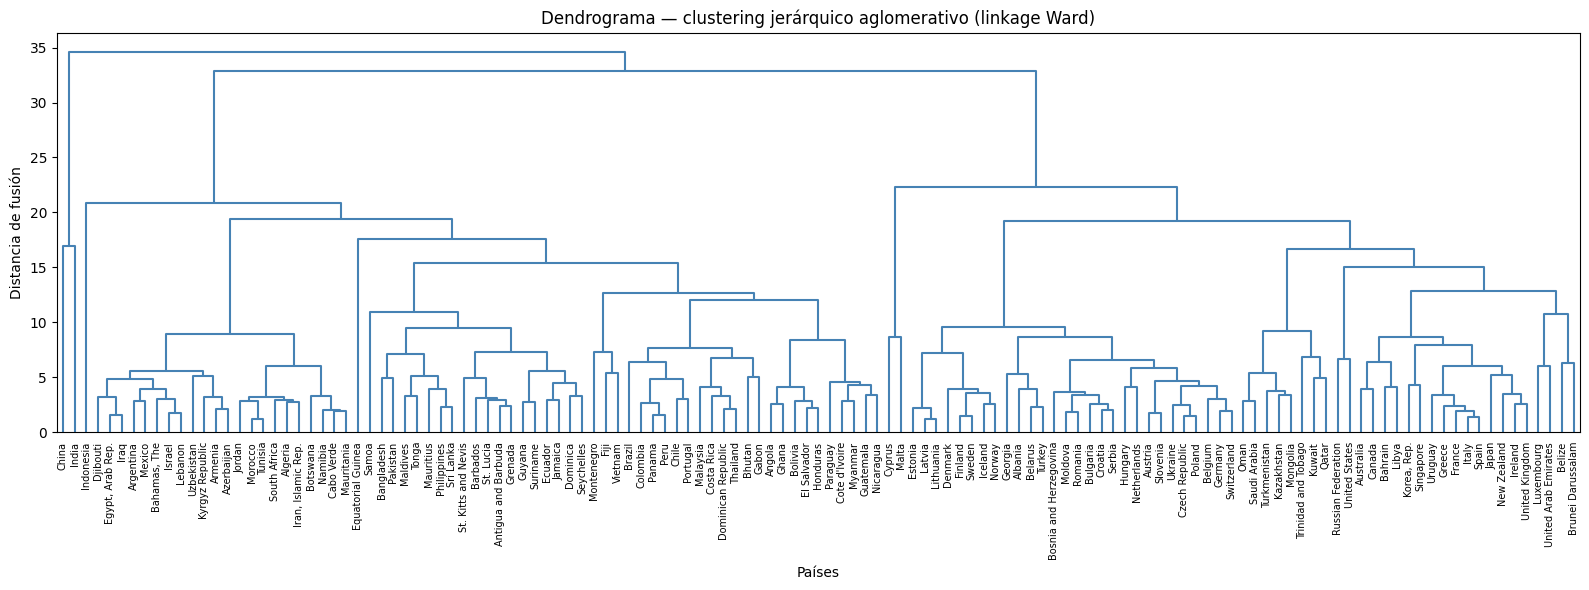


CONTRASTE KMEANS vs AGGLOMERATIVE CLUSTERING

Tabla cruzada (nº de países en cada combinación de etiquetas):
Agglomerative   0  1
KMeans              
0              73  0
1              54  2

Países con etiqueta coincidente entre ambos métodos: 75/129 (58.14%)
Adjusted Rand Index (ARI) entre KMeans y Agglomerative: 0.0099
  (1.0 = particiones idénticas; 0.0 = aleatorio; <0 = peor que aleatorio)

Países con asignación distinta entre los dos métodos (54):
  ['Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Bangladesh', 'Barbados', 'Belize', 'Bhutan', 'Bolivia', 'Botswana', 'Brazil', 'Cabo Verde', 'Colombia', 'Costa Rica', "Cote d'Ivoire", 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'El Salvador', 'Equatorial Guinea', 'Fiji', 'Gabon', 'Ghana', 'Grenada', 'Guatemala', 'Guyana', 'Honduras', 'Indonesia', 'Jamaica', 'Malaysia', 'Maldives', 'Mauritania', 'Mauritius', 'Morocco', 'Myanmar', 'Namibia', 'Nicaragua', 'Pakistan', 'Panama', 'Paraguay', 'Peru', 'Philippines', 'S

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# ----------------------------------------------------------------------
# 1) Entrenamiento del modelo jerárquico aglomerativo con K=2
# ----------------------------------------------------------------------
agglo = AgglomerativeClustering(n_clusters=2, linkage='ward')
etiquetas_agglo = agglo.fit_predict(df_paises_pca)

# Guardar etiquetas en df_clusters para mantener trazabilidad
df_clusters['cluster_agglo'] = etiquetas_agglo

print("Distribución de países por cluster (AgglomerativeClustering):")
distribucion_agglo = pd.Series(etiquetas_agglo).value_counts().sort_index()
print(distribucion_agglo.to_string())

print(f"\nSilhouette del modelo aglomerativo: "
      f"{silhouette_score(df_paises_pca, etiquetas_agglo):.4f}")

# ----------------------------------------------------------------------
# 2) Dendrograma — visualización de la estructura jerárquica
# ----------------------------------------------------------------------
matriz_linkage = linkage(df_paises_pca, method='ward')

plt.figure(figsize=(16, 6))
dendrogram(
    matriz_linkage,
    labels=df_paises_pca.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=7,
    color_threshold=0,
    above_threshold_color='steelblue',
)
plt.title("Dendrograma — clustering jerárquico aglomerativo (linkage Ward)")
plt.xlabel("Países")
plt.ylabel("Distancia de fusión")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 3) Tabla cruzada KMeans vs AgglomerativeClustering
# ----------------------------------------------------------------------
print("\n" + "=" * 60)
print("CONTRASTE KMEANS vs AGGLOMERATIVE CLUSTERING")
print("=" * 60)

tabla_cruzada = pd.crosstab(
    df_clusters['cluster_kmeans'],
    df_clusters['cluster_agglo'],
    rownames=['KMeans'],
    colnames=['Agglomerative'],
)
print("\nTabla cruzada (nº de países en cada combinación de etiquetas):")
print(tabla_cruzada)

# Coincidencia maximizando solapamiento (las etiquetas pueden estar permutadas)
n_total = len(df_clusters)
mejor_coincidencia = max(
    tabla_cruzada.iloc[0, 0] + tabla_cruzada.iloc[1, 1],
    tabla_cruzada.iloc[0, 1] + tabla_cruzada.iloc[1, 0],
)
pct_coincidencia = mejor_coincidencia / n_total * 100

print(f"\nPaíses con etiqueta coincidente entre ambos métodos: "
      f"{mejor_coincidencia}/{n_total} ({pct_coincidencia:.2f}%)")

# Adjusted Rand Index — métrica estándar para comparar particiones
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(etiquetas_kmeans, etiquetas_agglo)
print(f"Adjusted Rand Index (ARI) entre KMeans y Agglomerative: {ari:.4f}")
print("  (1.0 = particiones idénticas; 0.0 = aleatorio; <0 = peor que aleatorio)")

# ----------------------------------------------------------------------
# 4) Países que cambian de cluster entre los dos métodos
# ----------------------------------------------------------------------
# Reordenamos las etiquetas de Agglomerative para que coincidan en mayoría con KMeans
if (tabla_cruzada.iloc[0, 0] + tabla_cruzada.iloc[1, 1]) < (tabla_cruzada.iloc[0, 1] + tabla_cruzada.iloc[1, 0]):
    etiquetas_agglo_alineadas = 1 - etiquetas_agglo
else:
    etiquetas_agglo_alineadas = etiquetas_agglo

paises_discrepantes = df_clusters.index[etiquetas_kmeans != etiquetas_agglo_alineadas].tolist()
print(f"\nPaíses con asignación distinta entre los dos métodos ({len(paises_discrepantes)}):")
print(f"  {paises_discrepantes}")

### Conclusión del Hito 6

Apliqué clustering jerárquico aglomerativo con linkage Ward sobre la misma matriz `df_paises_pca` y corté la jerarquía en K=2 para tener una comparación directa con KMeans. El resultado es muy distinto al esperado y por sí mismo aporta información sobre la estructura del problema.

El jerárquico no reproduce el corte 73/56 del KMeans. Lo que hace es separar a China e India del resto del mundo: 127 países en el cluster 0 y solo 2 en el cluster 1. El dendrograma confirma esa lectura visualmente: la fusión más alta y aislada del árbol (a distancia ≈ 35) es la que une el bloque {China + India} con todos los demás países. Para Ward, ese corte minimiza la varianza de fusión más eficazmente que cualquier división equilibrada.

La tabla cruzada cuantifica la divergencia con claridad. Los 73 países que KMeans pone en el cluster 0 caen todos en el cluster 0 del jerárquico. De los 56 que KMeans pone en el cluster 1, 54 caen también en el cluster 0 del jerárquico y solo 2 (China e India) van al cluster 1. La coincidencia bruta de etiquetas es del 58.14%, pero el Adjusted Rand Index entre las dos particiones es **0.0099**, prácticamente equivalente a una asignación aleatoria. Las dos técnicas no están viendo la misma estructura.

El silhouette del jerárquico es 0.6454, muy superior al 0.1772 del KMeans. Pero ese valor no significa que el corte jerárquico sea "mejor": está inflado por el efecto típico de aislar dos puntos extremos. Cuando un cluster contiene solo 2 países geométricamente muy alejados del resto, su contribución al silhouette es alta y arrastra el promedio aunque la otra masa de 127 países sea internamente difusa. Es la misma trampa métrica que ya detectamos en el Hito 5 con K=4.

La interpretación honesta del contraste es esta: la división binaria del KMeans en 73/56 no es robusta a la elección del algoritmo. El jerárquico Ward, ante el mismo dato, prefiere aislar los outliers extremos en lugar de buscar dos masas equilibradas. Cada algoritmo aplica un criterio distinto (KMeans minimiza inercia y fuerza tamaños comparables, Ward minimiza varianza de fusión y prioriza la mayor separación geométrica) y esos criterios llevan a particiones casi independientes.

Esto refuerza una conclusión técnica importante del Hito 5: los 129 países no forman dos grupos compactos y geométricamente separables. La estructura subyacente es difusa y muy sensible a la sensibilidad de cada algoritmo a los outliers extremos. La división del KMeans (73 economías consolidadas vs 56 emergentes) tiene sentido cualitativo y permite construir el modelo supervisado del siguiente hito, pero hay que asumir que las fronteras entre grupos son metodológicas más que naturales.

Para el siguiente hito mantengo las pseudo-etiquetas de KMeans (`cluster_kmeans`) como variable objetivo, porque es el modelo principal que pide el enunciado y porque produce dos clusters utilizables; las del jerárquico (`cluster_agglo`) no son operativas para entrenar un clasificador (un cluster con solo 2 países deja stratify roto).

**Estado activo:** `df_clusters` (129 × 19, ahora con `cluster_kmeans` y `cluster_agglo`). Las pseudo-etiquetas para el modelo supervisado del próximo hito son `cluster_kmeans`.

## Hito 7 — Modelo supervisado con pseudo-etiquetas

Ahora entreno un modelo supervisado que aprenda a predecir, a partir de las features de dinámica que construí por país, a qué cluster pertenece. Las pseudo-etiquetas vienen del KMeans del Hito 5 (`cluster_kmeans`). Uso `df_paises` como matriz de entrada porque sus 36 columnas son interpretables (`b_mean`, `q_slope`, etc.) y eso me servirá en el siguiente hito para entender qué variables explican la pertenencia a cada grupo.

Aplico un split hold-out 80/20 estratificado por cluster con `random_state=33` y entreno un RandomForest con hiperparámetros conservadores. No aplico GridSearch porque el enunciado no lo exige y con solo 129 muestras añadir más complejidad aumenta el riesgo de sobreajuste. RandomForest no requiere escalado y da `feature_importances_` directo, lo que encaja con la interpretabilidad del siguiente hito.

Shape de X: (129, 36)
Shape de y: (129,)
Distribución de y: {0: 73, 1: 56}

Shape de X_train: (103, 36)
Shape de X_test:  (26, 36)
Distribución y_train: {0: 58, 1: 45}
Distribución y_test:  {0: 15, 1: 11}

Predictor trivial (siempre clase mayoritaria = 0):
  Accuracy: 0.5769
  F1 weighted: 0.4221

EVALUACIÓN EN TEST (única y final)
  Accuracy: 0.8846
  F1 weighted: 0.8851
  Mejora absoluta sobre predictor trivial: 0.3077 en accuracy / 0.4630 en F1

Reporte de clasificación por clase:
              precision    recall  f1-score   support

           0     0.9286    0.8667    0.8966        15
           1     0.8333    0.9091    0.8696        11

    accuracy                         0.8846        26
   macro avg     0.8810    0.8879    0.8831        26
weighted avg     0.8883    0.8846    0.8851        26

Matriz de confusión (valores absolutos):
[[13  2]
 [ 1 10]]


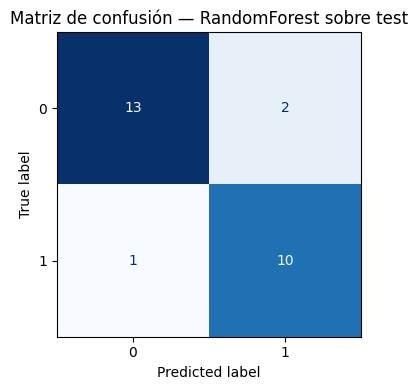


Países del test (26):
            pais  cluster_real  cluster_predicho  acierto
        Barbados             1                 1     True
         Finland             0                 0     True
          Jordan             0                 0     True
           Gabon             1                 1     True
Egypt, Arab Rep.             0                 1    False
        Botswana             1                 1     True
        Colombia             1                 1     True
         Grenada             1                 1     True
    Saudi Arabia             0                 0     True
         Moldova             0                 0     True
           Italy             0                 0     True
            Peru             1                 1     True
            Fiji             1                 1     True
       Nicaragua             1                 1     True
      Luxembourg             0                 0     True
     Korea, Rep.             0                 0 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score
)

random_seed = 33

# ----------------------------------------------------------------------
# 1) Preparación de X e y alineados por país
# ----------------------------------------------------------------------
# X: df_paises (features interpretables construidas en el Hito 3.5)
# y: cluster_kmeans (pseudo-etiquetas del Hito 5)
X = df_paises.copy()
y = df_clusters['cluster_kmeans']

# Comprobación dura: índices alineados
assert X.index.equals(y.index), "Los índices de X e y no están alineados."
print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"Distribución de y: {y.value_counts().sort_index().to_dict()}")

# ----------------------------------------------------------------------
# 2) Split estratificado 80/20
# ----------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=random_seed,
)

print(f"\nShape de X_train: {X_train.shape}")
print(f"Shape de X_test:  {X_test.shape}")
print(f"Distribución y_train: {y_train.value_counts().sort_index().to_dict()}")
print(f"Distribución y_test:  {y_test.value_counts().sort_index().to_dict()}")

# ----------------------------------------------------------------------
# 3) Entrenamiento RandomForest con hiperparámetros conservadores
# ----------------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=5,
    random_state=random_seed,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

# ----------------------------------------------------------------------
# 4) Predictor trivial — referencia obligatoria de comparación
# ----------------------------------------------------------------------
clase_mayoritaria = y_train.value_counts().idxmax()
y_pred_trivial = np.full(len(y_test), clase_mayoritaria)
acc_trivial = accuracy_score(y_test, y_pred_trivial)
f1_trivial = f1_score(y_test, y_pred_trivial, average='weighted')

print(f"\nPredictor trivial (siempre clase mayoritaria = {clase_mayoritaria}):")
print(f"  Accuracy: {acc_trivial:.4f}")
print(f"  F1 weighted: {f1_trivial:.4f}")

# ----------------------------------------------------------------------
# 5) Evaluación única en test (regla del test sagrado)
# ----------------------------------------------------------------------
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1_w = f1_score(y_test, y_pred, average='weighted')

print(f"\n{'=' * 60}")
print("EVALUACIÓN EN TEST (única y final)")
print('=' * 60)
print(f"  Accuracy: {acc:.4f}")
print(f"  F1 weighted: {f1_w:.4f}")
print(f"  Mejora absoluta sobre predictor trivial: {(acc - acc_trivial):.4f} en accuracy / {(f1_w - f1_trivial):.4f} en F1")

# Reporte detallado por clase
print("\nReporte de clasificación por clase:")
print(classification_report(y_test, y_pred, digits=4))

# Matriz de confusión
print("Matriz de confusión (valores absolutos):")
matriz_conf = confusion_matrix(y_test, y_pred)
print(matriz_conf)

# Visualización de la matriz
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(matriz_conf, display_labels=[0, 1]).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Matriz de confusión — RandomForest sobre test")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 6) Países del test y predicción
# ----------------------------------------------------------------------
df_test_resultados = pd.DataFrame({
    'pais': X_test.index,
    'cluster_real': y_test.values,
    'cluster_predicho': y_pred,
    'acierto': y_test.values == y_pred,
})
print(f"\nPaíses del test ({len(df_test_resultados)}):")
print(df_test_resultados.to_string(index=False))

n_errores = (~df_test_resultados['acierto']).sum()
if n_errores > 0:
    print(f"\nPaíses mal clasificados ({n_errores}):")
    print(df_test_resultados[~df_test_resultados['acierto']].to_string(index=False))
else:
    print("\nNo hay errores: todos los países del test bien clasificados.")

### Conclusión del Hito 7

Apliqué un split hold-out 80/20 estratificado por cluster con `random_state=33` sobre `df_paises` (129 países × 36 features). Quedaron 103 países en train (58 cluster 0, 45 cluster 1) y 26 en test (15 cluster 0, 11 cluster 1), con la distribución de clusters preservada por la estratificación.

Entrené un RandomForest con `n_estimators=100`, `max_depth=5`, `min_samples_split=5` y `random_state=33`. No requirió escalado (modelo basado en árboles) ni búsqueda de hiperparámetros (el enunciado no la exige y con 129 muestras añadir GridSearch supondría un riesgo de sobreajuste innecesario).

En test el modelo obtiene **accuracy = 0.8846** y **F1 weighted = 0.8851**. El predictor trivial (siempre la clase mayoritaria) habría obtenido accuracy 0.5769 y F1 0.4221, lo que da una referencia clara: el modelo mejora 30.77 puntos en accuracy y 46.30 puntos en F1 sobre la baseline ingenua. La mejora es sustancial y demuestra que las features de dinámica capturan información real sobre la pertenencia a cada grupo, no son ruido.

Las métricas por clase son equilibradas: cluster 0 con precision 0.9286, recall 0.8667 y F1 0.8966; cluster 1 con precision 0.8333, recall 0.9091 y F1 0.8696. Ninguna clase está degenerada, ambas se predicen con calidad similar.

La matriz de confusión muestra 3 errores sobre 26 (11.5%), distribuidos como 2 falsos positivos del cluster 1 y 1 falso negativo. Los países mal clasificados son particularmente informativos:

- **Egipto** y **México** son economías que KMeans había asignado al cluster de consolidados (cluster 0) pero el modelo lee como emergentes. Ambos son países grandes con estructura mixta donde la frontera entre "consolidado" y "en desarrollo" es discutible.
- **Sudáfrica** va en sentido opuesto: KMeans la pone con los emergentes pero el modelo la clasifica como consolidada. Coherente con su perfil BRICS, con sectores muy desarrollados conviviendo con desigualdad estructural.

Los tres errores caen exactamente sobre la frontera difusa que ya identificamos en el Hito 5 (silhouette modesto, divergencia con el jerárquico). El modelo no falla por aleatoriedad sino por la ambigüedad real del problema en la zona de transición entre los dos grupos.

**Estado activo:** modelo `rf` entrenado y disponible, `X_train`, `X_test`, `y_train`, `y_test` separados. En el siguiente hito uso `rf.feature_importances_` para identificar qué features explican la pertenencia a cada cluster.

## Hito 8 — Interpretación del modelo y variables más explicativas

Para cerrar el problema interpreto el RandomForest entrenado en el paso anterior y veo qué features tiraron más del clasificador. Uso `feature_importances_` del propio modelo, ordeno las 36 features de mayor a menor relevancia y miro de cerca las 10 más importantes. Como el barplot por sí solo no explica la dirección de la discriminación, complemento con boxplots y una tabla numérica que muestran cómo se distribuye cada feature entre los dos clusters. Con eso puedo justificar no solo qué variables importan, sino en qué sentido separan a los países consolidados de los emergentes.

Importancia de las 36 features (ordenadas):
feature  importancia
 m_mean     0.139879
  m_std     0.121186
 g_mean     0.092058
e_slope     0.088487
 r_mean     0.075375
 j_mean     0.075275
m_slope     0.061070
 n_mean     0.049690
 h_mean     0.031781
r_slope     0.028149
  n_std     0.025853
  g_std     0.023676
g_slope     0.018299
c_slope     0.017146
h_slope     0.016130
 l_mean     0.012930
 e_mean     0.011180
j_slope     0.011132
  c_std     0.010961
n_slope     0.010758
  j_std     0.009512
 q_mean     0.007931
  h_std     0.007917
  r_std     0.007214
  e_std     0.006535
 o_mean     0.005941
 c_mean     0.005824
o_slope     0.005530
  q_std     0.004014
  b_std     0.003792
q_slope     0.003711
  o_std     0.003273
 b_mean     0.002755
  l_std     0.002443
b_slope     0.001743
l_slope     0.000852


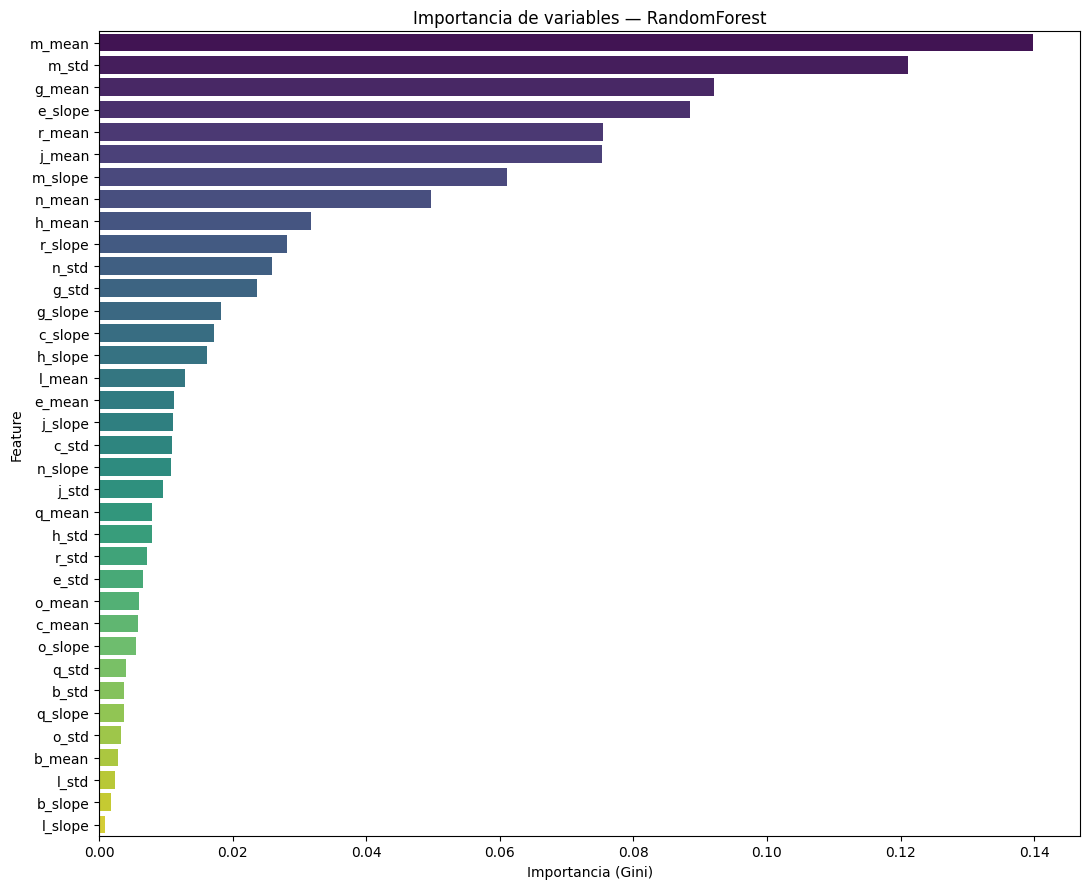


Top 10 features más importantes: ['m_mean', 'm_std', 'g_mean', 'e_slope', 'r_mean', 'j_mean', 'm_slope', 'n_mean', 'h_mean', 'r_slope']

Distribución de las top 10 features por cluster (media y mediana):
feature  mean_cluster_0  mean_cluster_1  median_cluster_0  median_cluster_1  ratio_medias_0_sobre_1
 m_mean         13.1269         23.9673           11.3500           24.9321                  0.5477
  m_std          0.5405          0.2729            0.5299            0.2418                  1.9810
 g_mean         73.0775         49.8108           73.8796           50.0414                  1.4671
e_slope          0.2409         -0.5328            0.1515           -0.4188                 -0.4522
 r_mean         11.7119          4.9132            9.1129            3.3782                  2.3838
 j_mean          4.9503          2.4147            4.8101            2.3880                  2.0500
m_slope          0.0405          0.0161            0.0400            0.0146                  2.

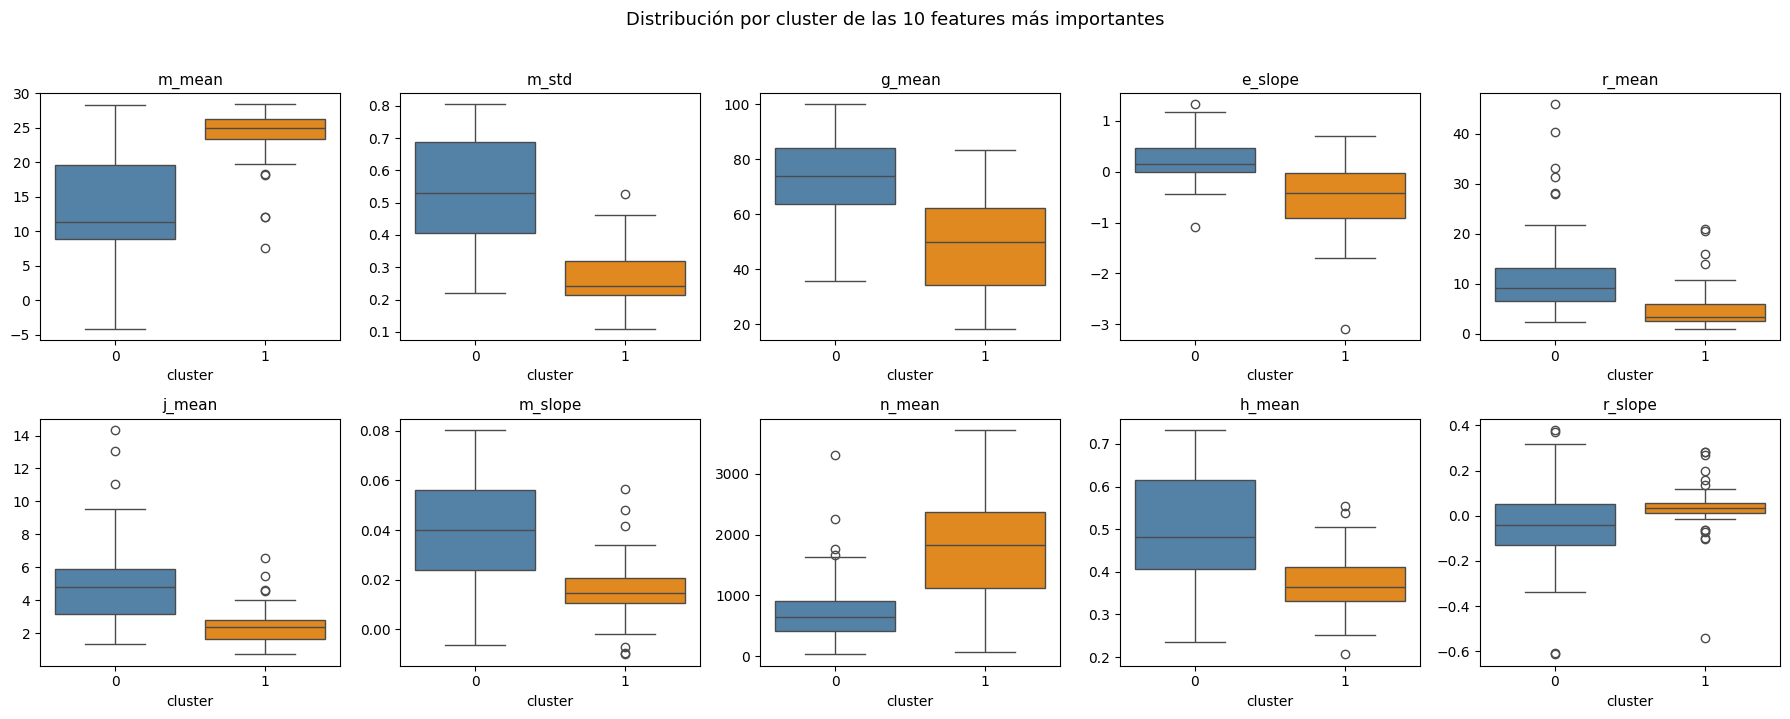


Suma de importancia por tipo de estadístico:
estadistico
mean     0.5106
slope    0.2630
std      0.2264

Suma de importancia por indicador anonimizado (12 indicadores):
indicador
m    0.3221
g    0.1340
r    0.1107
e    0.1062
j    0.0959
n    0.0863
h    0.0558
c    0.0339
l    0.0162
q    0.0157
o    0.0147
b    0.0083


In [ ]:
# ----------------------------------------------------------------------
# 1) Importancia de variables del RandomForest entrenado en el Hito 7
# ----------------------------------------------------------------------
importancias = pd.DataFrame({
    'feature': X_train.columns,
    'importancia': rf.feature_importances_,
}).sort_values('importancia', ascending=False).reset_index(drop=True)

print("Importancia de las 36 features (ordenadas):")
print(importancias.to_string(index=False))

# ----------------------------------------------------------------------
# 2) Barplot de las 36 features
# ----------------------------------------------------------------------
plt.figure(figsize=(11, 9))
sns.barplot(
    data=importancias,
    y='feature',
    x='importancia',
    hue='feature',
    palette='viridis',
    legend=False,
)
plt.title("Importancia de variables — RandomForest")
plt.xlabel("Importancia (Gini)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 3) Top 10 features y su distribución por cluster
# ----------------------------------------------------------------------
top10 = importancias.head(10)['feature'].tolist()
print(f"\nTop 10 features más importantes: {top10}")

# Tabla numérica auxiliar: media y mediana por cluster en cada top feature
df_paises_con_cluster = df_paises.copy()
df_paises_con_cluster['cluster'] = df_clusters['cluster_kmeans']

resumen_top10 = []
for feat in top10:
    grupos = df_paises_con_cluster.groupby('cluster')[feat].agg(['mean', 'median'])
    resumen_top10.append({
        'feature': feat,
        'mean_cluster_0': grupos.loc[0, 'mean'],
        'mean_cluster_1': grupos.loc[1, 'mean'],
        'median_cluster_0': grupos.loc[0, 'median'],
        'median_cluster_1': grupos.loc[1, 'median'],
        'ratio_medias_0_sobre_1': grupos.loc[0, 'mean'] / grupos.loc[1, 'mean'] if grupos.loc[1, 'mean'] != 0 else np.nan,
    })

tabla_top10 = pd.DataFrame(resumen_top10)
print("\nDistribución de las top 10 features por cluster (media y mediana):")
print(tabla_top10.round(4).to_string(index=False))

# ----------------------------------------------------------------------
# 4) Boxplots de las top 10 features por cluster
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, feat in zip(axes.flatten(), top10):
    sns.boxplot(
        data=df_paises_con_cluster,
        x='cluster',
        y=feat,
        hue='cluster',
        ax=ax,
        palette={0: 'steelblue', 1: 'darkorange'},
        legend=False,
    )
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel('cluster')
    ax.set_ylabel('')
fig.suptitle("Distribución por cluster de las 10 features más importantes", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 5) Resumen agregado: qué tipo de estadístico y qué indicadores dominan
# ----------------------------------------------------------------------
# Cada feature es del tipo "{indicador}_{estadistico}"
importancias['indicador'] = importancias['feature'].str.split('_').str[0]
importancias['estadistico'] = importancias['feature'].str.split('_').str[1]

por_estadistico = importancias.groupby('estadistico')['importancia'].sum().sort_values(ascending=False)
por_indicador = importancias.groupby('indicador')['importancia'].sum().sort_values(ascending=False)

print("\nSuma de importancia por tipo de estadístico:")
print(por_estadistico.round(4).to_string())

print("\nSuma de importancia por indicador anonimizado (12 indicadores):")
print(por_indicador.round(4).to_string())

### Conclusión del Hito 8

El RandomForest se apoya en un grupo reducido de features para distinguir los dos clusters. Las cinco más importantes (`m_mean` 13.99%, `m_std` 12.12%, `g_mean` 9.21%, `e_slope` 8.85% y `r_mean` 7.54%) acumulan el 51.7% de la importancia total. La feature más relevante es `m_mean`: el nivel medio del indicador `m` por país durante el periodo 1995-2020.

Mirando la distribución de las 10 features más importantes por cluster, la separación tiene una estructura clara y contrasta lo que podría parecer una jerarquía simple "ricos vs pobres":

- En el cluster 0 (consolidados) son más altos `g_mean` (mediana 74 vs 50), `r_mean` (9 vs 3), `j_mean` (5 vs 2.4) y `h_mean` (0.48 vs 0.36).
- En el cluster 1 (emergentes) son más altos `m_mean` (mediana 25 vs 11) y `n_mean` (1836 vs 644).
- Las pendientes apuntan en direcciones opuestas: `e_slope` es positivo en el cluster 0 (+0.15) y negativo en el cluster 1 (-0.42); `r_slope` al revés.

Es decir, los grupos no se ordenan en una sola escala sino que son **perfiles cualitativamente distintos**: el cluster 0 destaca en algunos indicadores y trayectorias, el cluster 1 en otros, y las tendencias temporales van en sentidos opuestos en `e` y `r`. Esto da una interpretación más rica que un simple "consolidados vs emergentes": son dos modelos económicos con dinámicas estructuralmente diferentes.

Agrupando la importancia por tipo de estadístico, el modelo se apoya principalmente en niveles medios:

- **mean**: 51.08% del total → el nivel medio histórico de los indicadores es el principal eje de separación.
- **slope**: 26.28% → la tendencia temporal aporta una cuarta parte de la información discriminante.
- **std**: 22.64% → la volatilidad pesa algo menos pero sigue siendo relevante.

La conclusión es que **la dimensión más explicativa es dónde está cada país** (nivel) y la siguiente es **hacia dónde va** (tendencia), lo cual encaja perfectamente con el espíritu del enunciado: "dinámica de cada país a lo largo del tiempo".

Por indicador anonimizado, hay una concentración muy clara en pocas variables:

- `m`: 32.21% del total. Es **con diferencia el indicador más explicativo**, multiplicando casi por 2.5 al siguiente.
- `g`: 13.40%, `r`: 11.07%, `e`: 10.62%, `j`: 9.60%, `n`: 8.64%.
- Los seis primeros indicadores acumulan el 85.94% de la importancia. Los indicadores `b`, `o`, `q`, `l` aportan menos del 2% cada uno y prácticamente no discriminan.

Esto sugiere que, aunque el dataset venía con 12 indicadores anonimizados, **la mayor parte de la información útil para diferenciar países está en 5-6 de ellos**. Los demás añaden ruido o información redundante.

Sobre los tres errores del Hito 7 (Egipto, México y Sudáfrica), tienen sentido a la luz de esta interpretación: son países con valores intermedios en las features dominantes, exactamente en la zona de solape entre los dos boxplots. El modelo no falla por aleatoriedad sino por la frontera difusa que ya identificamos como propiedad real del dataset desde el Hito 5.

Con esto cierro el problema. La división binaria del KMeans, validada por el modelo supervisado con 88.46% de accuracy y explicada por las features de dinámica, agrupa coherentemente a los 129 países en dos perfiles económicos diferenciables a partir de su evolución entre 1995 y 2020. Los grupos no son geométricamente compactos (silhouette 0.18, divergencia con el clustering jerárquico) pero sí cualitativamente coherentes y predictivamente útiles.

# Conclusiones generales

He resuelto el problema en dos grandes bloques. Primero construí un perfil dinámico por país a partir de las series temporales 1995-2020, resumiendo cada uno de los 12 indicadores conservados en tres estadísticos (media, desviación y pendiente). Sobre esa matriz de 129 países × 36 features apliqué escalado y PCA al 90% de varianza, obteniendo 17 componentes que entraron al clustering.

KMeans con tres técnicas de optimización (codo, silhouette y Davies-Bouldin) apuntaba inicialmente a K=4, pero la verificación de composición reveló que ese K aislaba outliers extremos (China, India, Chipre, Malta) en clusters degenerados. Adopté K=2 como el único valor que producía una división utilizable: 73 países con perfil de economía consolidada y 56 con perfil emergente. El contraste con clustering jerárquico Ward dio una partición distinta (ARI ≈ 0), lo que documenté como evidencia de que la división no es geométricamente nítida sino metodológica.

El RandomForest entrenado con esas pseudo-etiquetas alcanza 88.46% de accuracy y 0.8851 de F1 weighted en test, con 30 puntos de mejora sobre el predictor trivial. Los tres errores caen en países de frontera (Egipto, México, Sudáfrica), coherentes con la ambigüedad estructural ya identificada. La interpretación final muestra que el modelo se apoya sobre todo en niveles medios (51% de la importancia) y en un grupo reducido de indicadores, dominados por `m` (32% del peso total).

La conclusión global es que los 129 países se agrupan en dos perfiles económicos diferenciables a partir de su evolución temporal, con fronteras difusas pero predictivamente útiles, y con `m`, `g`, `r`, `e` y `j` como las variables que mejor explican la pertenencia a cada grupo.